In [ ]:
#Extract the lorentz corrections
#cifpets=input('what is the cif.pets pathway? ')
cifpets='/content/p2_a_original.cif_pets'
lpfile='/content/p2_ab_lp.txt'
gmagcsv="/content/abiraterone_Ug_values.csv"
#lpfile=input('What is the lorentz pathway? ')
# read whole file as text
with open(cifpets) as f:
    text = f.read()

# find the *last* loop_ block
last_loop = text.rsplit("loop_", 1)[-1].strip().splitlines()

# expected headers
headers = [
"_refln_index_h",
"_refln_index_k",
"_refln_index_l",
"_refln_intensity_meas",
"_refln_intensity_sigma",
"_refln_zone_axis_id"
]


# find where numeric data starts
data_start = next(i for i, line in enumerate(last_loop) if line.strip() and not line.startswith("_"))
rows = last_loop[data_start:]

# build dictionary: each key -> list of values
data = {h: [] for h in headers}

for row in rows:
    parts = row.split()
    if len(parts) != len(headers):
        break  # stop if next loop starts
    for h, v in zip(headers, parts):
        data[h].append(float(v))

# data now contains the extracted data
'''
#check for first row of data
i = 0
print("\nFirst reflection:")
print("hkl              =", (
    int(data["_refln_index_h"][i]),
    int(data["_refln_index_k"][i]),
    int(data["_refln_index_l"][i]),
))
print("intensity_meas   =", data["_refln_intensity_meas"][i])
print("intensity_sigma  =", data["_refln_intensity_sigma"][i])
print("zone_axis_id     =", int(data["_refln_zone_axis_id"][i]))
'''

#
#
#
#

"""
!!! Now I shall look at getting the g_mag values from the csv file !!!

"""
#Extract g_mag from the csv containing the Ug values from refinement
import csv

# --- build lookup table from CSV: hkl tuple -> g_mag ---
gmag_lookup = {}
U_g_lookup={}
with open(gmagcsv, newline="") as f:
    reader = csv.DictReader(f, delimiter=",")
    reader.fieldnames = [name.strip() for name in reader.fieldnames]  # FIX
    for row in reader:
        hkl = tuple(int(x) for x in row["hkl"].strip("()").split(","))
        gmag_lookup[hkl] = float(row["g_mag"])
        U_g_real = float(row["U_g_real"])
        U_g_imag = float(row["U_g_imag"])
        U_g= (U_g_real**2+U_g_imag**2)**0.5
        U_g_lookup[hkl]=U_g



# --- attach g_mag to zone_axis_dict ---
# existing code: gmag_lookup already built

data["g_mag"] = []
missing_hkl = []
data["U_g"] = []
missing_U_g = []
for h, k, l in zip(
    data["_refln_index_h"],
    data["_refln_index_k"],
    data["_refln_index_l"],
):
    key = (int(h), int(k), int(l))

    if key in gmag_lookup:
        data["g_mag"].append(gmag_lookup[key])
    else:
        data["g_mag"].append(None)
        missing_hkl.append(key)
    if key in U_g_lookup:
        data["U_g"].append(U_g_lookup[key])
    else:
        data["U_g"].append(None)
        missing_U_g.append(key)

# report problems clearly
'''if missing_hkl:
    raise KeyError(f"{len(set(missing_hkl))} HKLs missing from g_mag CSV")
    print("ERROR: g_mag not found for the following HKLs:")
    for hk in sorted(set(missing_hkl)):
        print("  missing hkl:", hk)
'''



#print(len(data))

"""
!!! Now I shall look at getting the lorentz factors from the csv file !!!

"""

# path to the text file containing lp

# build lp lookup
lp_lookup = {}
with open(lpfile) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):  # skip empty or comment lines
            continue
        parts = line.split()
        if len(parts) != 4:
            continue  # skip malformed lines
        h, k, l, lp = parts
        key = (int(h), int(k), int(l))
        lp_lookup[key] = float(lp)

# add lp to your data dictionary
data["lp"] = []
missing_lp = []

for h, k, l in zip(
    data["_refln_index_h"],
    data["_refln_index_k"],
    data["_refln_index_l"]
):
    key = (int(h), int(k), int(l))
    if key in lp_lookup:
        data["lp"].append(lp_lookup[key])
    else:
        data["lp"].append(None)
        missing_lp.append(key)

# report any missing reflections
if missing_lp:
    print("WARNING: LP factor not found for the following HKLs:")
    for hk in sorted(set(missing_lp)):
        print("  missing hkl:", hk)
print(list(data.keys()))
print('Missing lps amount is ',len(set(missing_lp)))


  missing hkl: (-8, -2, -4)
  missing hkl: (-8, -2, -3)
  missing hkl: (-8, -2, -2)
  missing hkl: (-8, -2, 0)
  missing hkl: (-8, -2, 2)
  missing hkl: (-8, -2, 3)
  missing hkl: (-8, -2, 4)
  missing hkl: (-8, -1, -6)
  missing hkl: (-8, -1, -5)
  missing hkl: (-8, -1, -4)
  missing hkl: (-8, -1, -2)
  missing hkl: (-8, -1, 0)
  missing hkl: (-8, -1, 1)
  missing hkl: (-8, -1, 3)
  missing hkl: (-8, -1, 4)
  missing hkl: (-8, -1, 5)
  missing hkl: (-8, 0, -7)
  missing hkl: (-8, 0, -6)
  missing hkl: (-8, 0, -5)
  missing hkl: (-8, 0, -4)
  missing hkl: (-8, 0, -3)
  missing hkl: (-8, 0, -2)
  missing hkl: (-8, 0, -1)
  missing hkl: (-8, 0, 1)
  missing hkl: (-8, 0, 4)
  missing hkl: (-8, 0, 5)
  missing hkl: (-8, 0, 7)
  missing hkl: (-8, 1, -6)
  missing hkl: (-8, 1, -5)
  missing hkl: (-8, 1, -4)
  missing hkl: (-8, 1, -3)
  missing hkl: (-8, 1, -2)
  missing hkl: (-8, 1, -1)
  missing hkl: (-8, 1, 1)
  missing hkl: (-8, 1, 2)
  missing hkl: (-8, 1, 4)
  missing hkl: (-8, 1, 5)
  

In [ ]:
#Add 3 sigma filter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# convert dictionary to DataFrame
dataf = pd.DataFrame(data)


df  = dataf[dataf['_refln_intensity_meas'] >= 3 * dataf['_refln_intensity_sigma']].copy()
df2 = dataf
df3 = dataf[dataf['_refln_intensity_meas'] >= 5 * dataf['_refln_intensity_sigma']].copy()
df7 = dataf[dataf['_refln_intensity_meas'] >= 7 * dataf['_refln_intensity_sigma']].copy()
df9 = dataf[dataf['_refln_intensity_meas'] >= 9 * dataf['_refln_intensity_sigma']].copy()


print(plt.style.available)
plt.style.use('ggplot')

'''
sum_zone1 = df.loc[df['_refln_zone_axis_id'] == 1, 'lpcorrected_intensity'].sum()
scales=[]
for zone in range(1,int(np.max(np.array(df['_refln_zone_axis_id'])))+1):
    sum_zone = df.loc[df['_refln_zone_axis_id'] == zone, 'lpcorrected_intensity'].sum()
    scale = sum_zone1 / sum_zone
    #df.loc[df['_refln_zone_axis_id'] == zone, 'lpcorrected_intensity'] *= scale
    scales.append(scale)
plt.plot(np.arange(1,int(np.max(np.array(df['_refln_zone_axis_id'])))+1), scales)
plt.show()
'''
# --- write data dictionary to CSV ---

import csv

out_csv = "extracted_reflection_data.csv"

# use dictionary keys as column headers
fieldnames = list(data.keys())

with open(out_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(fieldnames)

    # number of rows = length of any column
    nrows = len(data[fieldnames[0]])

    for i in range(nrows):
        writer.writerow([data[key][i] for key in fieldnames])

print(f"Saved CSV to: {out_csv}")


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
Saved CSV to: extracted_reflection_data.csv


Repeated HKLs (appear more than once) with their orientations:
     _refln_index_h  _refln_index_k  _refln_index_l  count  \
0              -7.0            -1.0            -2.0      3   
1              -6.0            -3.0             0.0      4   
2              -6.0            -1.0            -5.0      3   
3              -6.0            -1.0            -4.0      3   
4              -6.0            -1.0            -2.0      3   
..              ...             ...             ...    ...   
808             6.0             1.0             3.0      3   
809             6.0             1.0             4.0      3   
810             6.0             1.0             5.0      3   
811             6.0             3.0             0.0      3   
812             6.0             3.0             3.0      3   

                 orientations  
0          [32.0, 33.0, 34.0]  
1    [37.0, 38.0, 39.0, 40.0]  
2          [22.0, 23.0, 24.0]  
3          [25.0, 26.0, 27.0]  
4          [31.0, 32.0, 33.0]  


/tmp/ipykernel_19499/2468117059.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.dropna(subset=["g_mag", "lp"], inplace=True)
/tmp/ipykernel_19499/2468117059.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["lpcorrected_intensity"] = d["_refln_intensity_meas"] * d["lp"]
/tmp/ipykernel_19499/2468117059.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d.dropna(subse

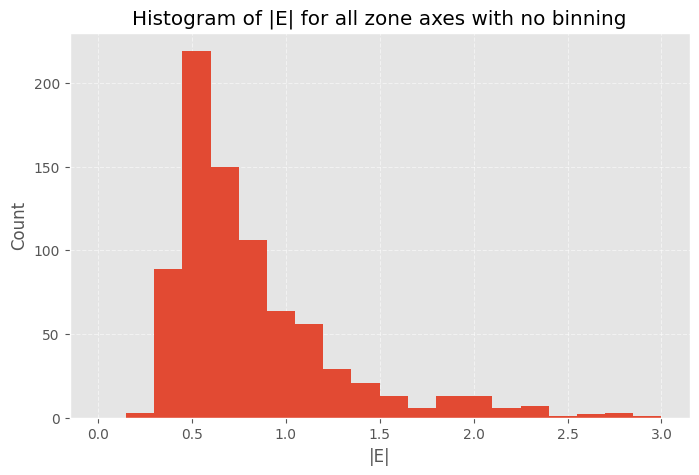

In [ ]:
#plots the |E| histograms with no binning

import pandas as pd

# Combine all dataframes if you want to check across them, or just use df
df_all = df.copy()  # or pd.concat([df, df2, df3, df7, df9], ignore_index=True)

# Group by HKL indices and collect zone IDs where they appear
hkl_groups = df_all.groupby(['_refln_index_h', '_refln_index_k', '_refln_index_l'])

# Build table: count of occurrences and list of orientations
hkl_summary = hkl_groups['_refln_zone_axis_id'].agg(['count', lambda x: list(x)]).reset_index()
hkl_summary.rename(columns={'<lambda_0>': 'orientations'}, inplace=True)

# Only keep repeated HKLs (count > 1)
repeated_hkls = hkl_summary[hkl_summary['count'] > 1]

# Display
print("Repeated HKLs (appear more than once) with their orientations:")
print(repeated_hkls)

# Optional: save to CSV
repeated_hkls.to_csv("repeated_hkls.csv", index=False)
'''
bad_hkls = hkl_summary[hkl_summary['count'] > 4][['_refln_index_h','_refln_index_k','_refln_index_l']]

for name in ["df", "df2", "df3", "df7", "df9"]:
    globals()[name] = globals()[name].merge(
        bad_hkls,
        on=['_refln_index_h','_refln_index_k','_refln_index_l'],
        how='left',
        indicator=True
    )
    globals()[name] = globals()[name][globals()[name]['_merge'] == 'left_only'].drop(columns=['_merge'])

print("After removal:")
print("df :", len(df))
print("df2:", len(df2))
print("df3:", len(df3))
print("df7:", len(df7))
print("df9:", len(df9))
'''

# convert lists to NumPy arrays
g_mag = np.array(data['g_mag'], dtype=float)
print(g_mag)


# compute s/2 squared
s_2 = (g_mag / 2) ** 2
print(s_2)
print(df.columns)
n_before = len(df)
n_before2 = len(df2)

print("Total rows before with 3 sigma filter:", n_before)
print("Total rows before with no sigma filter:", n_before2)
df_unique  = df.drop_duplicates(subset=["_refln_index_h", "_refln_index_k", "_refln_index_l"], keep="first")
df2_unique = df2.drop_duplicates(subset=["_refln_index_h", "_refln_index_k", "_refln_index_l"], keep="first")
df3_unique = df3.drop_duplicates(subset=["_refln_index_h", "_refln_index_k", "_refln_index_l"], keep="first")
df7_unique = df7.drop_duplicates(subset=["_refln_index_h", "_refln_index_k", "_refln_index_l"], keep="first")
df9_unique = df9.drop_duplicates(subset=["_refln_index_h", "_refln_index_k", "_refln_index_l"], keep="first")
print('hi the number of reflections in the first one is, ',df['_refln_zone_axis_id'].value_counts().sort_index())


n_after = len(df_unique)
print("Unique HKLs after with 3 sigma:", n_after)
n_after2 = len(df2_unique)
print("Unique HKLs after with no sigma:", n_after2)

print('length of df before dropping the ones with no lp and 3 sigma is ',len(df_unique))
print('length of df before dropping the ones with no lp and no sigma is ',len(df2_unique))
for d in [df3_unique, df2_unique, df_unique, df7_unique, df9_unique]:
    d.dropna(subset=["g_mag", "lp"], inplace=True)
    d["lpcorrected_intensity"] = d["_refln_intensity_meas"] * d["lp"]
print('length of df after dropping the ones with no lp and 3 sigma is ',len(df_unique))
print('length of df after dropping the ones with no lp and no sigma is ',len(df2_unique))


lpcorr = np.array(df_unique['lpcorrected_intensity'], dtype=float)

E2 = lpcorr / np.mean(lpcorr)
E = np.sqrt(E2)


mask_cut = (E < 3)  # boolean array
E = E[mask_cut]
plt.figure(figsize=(8,5))
plt.hist(E, np.linspace(0, 3, 21))
plt.xlabel('|E|')
plt.ylabel('Count')
plt.title('Histogram of |E| for all zone axes with no binning')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.close()



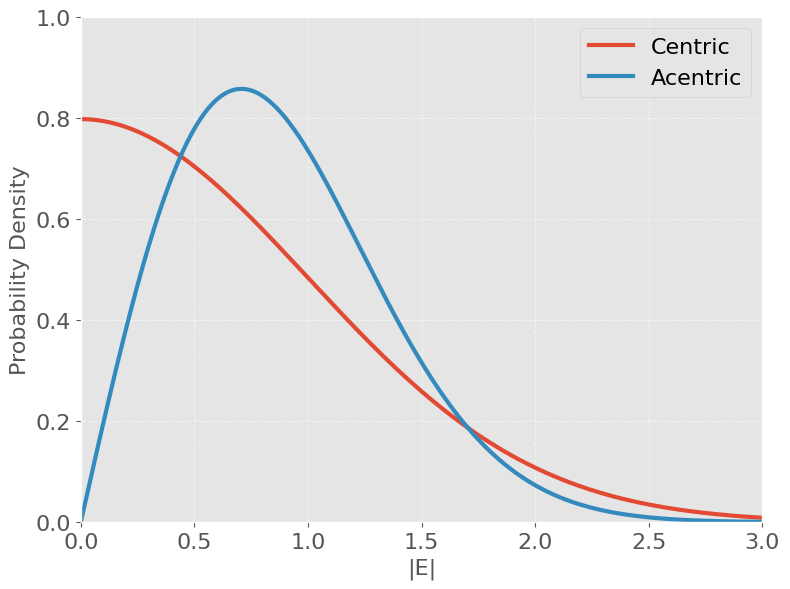

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

E_theory = np.linspace(0, 3, 400)
centric_theory = np.sqrt(2/np.pi) * np.exp(-(E_theory**2)/2)
acentric__theory = 2*E_theory*np.exp(-(E_theory**2))
plt.figure(figsize=(8,6))
plt.plot(E_theory, centric_theory, lw=3, label="Centric")
plt.plot(E_theory, acentric__theory, lw=3, label="Acentric")
plt.xlabel('|E|', size=16)
plt.ylabel('Probability Density', size=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 3)
plt.ylim(0,1)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.savefig('theory.pdf',dpi=600)
plt.tight_layout()
plt.show()
plt.close()




757


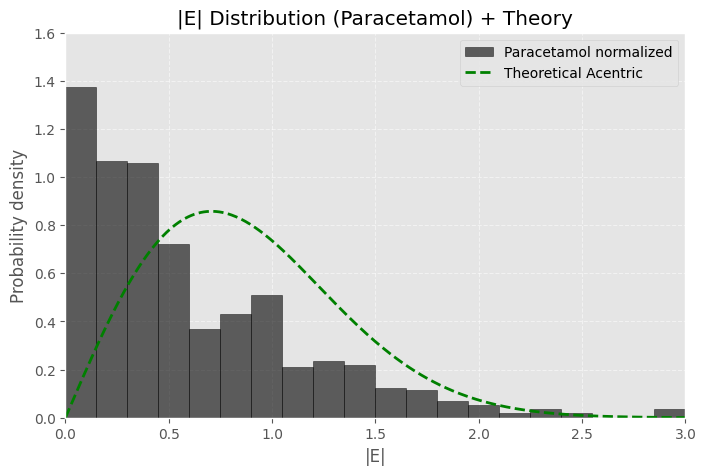

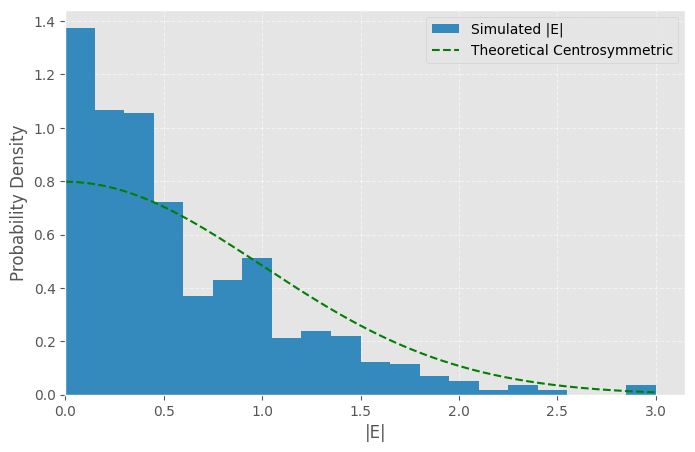

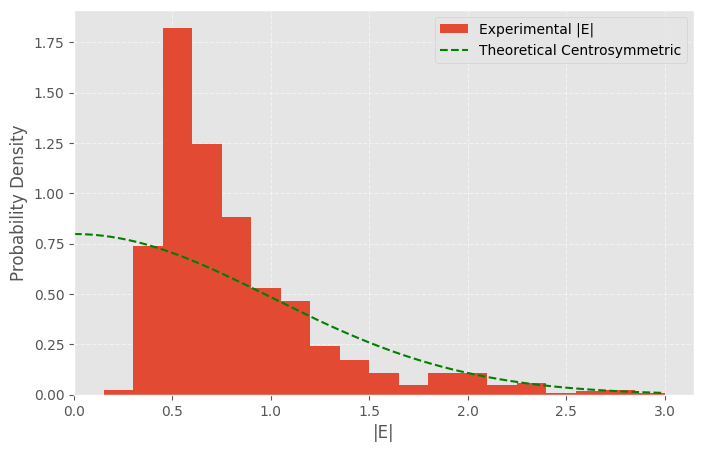

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

# ------------------------------
# Function to read and process a simulated Ug CSV
# ------------------------------
def process_ug_file(filename, df_hkl_filtered, sigma_cut=3):
    df = pd.read_csv(filename)
    df[["h","k","l"]] = df["hkl"].str.strip("()").str.split(",", expand=True).astype(int)
    df["U_g_mag"] = np.sqrt(df["U_g_real"]**2 + df["U_g_imag"]**2)

    df_filtered = df.merge(
        df_hkl_filtered[["_refln_index_h","_refln_index_k","_refln_index_l"]],
        left_on=["h","k","l"],
        right_on=["_refln_index_h","_refln_index_k","_refln_index_l"],
        how="inner"
    )

    kinetic_inten = df_filtered["U_g_mag"].to_numpy(dtype=float)**2
    E_vals = np.sqrt(kinetic_inten / np.mean(kinetic_inten))
    E_vals = E_vals[E_vals < sigma_cut]
    print(len(E_vals))
    return E_vals

# ------------------------------
# Gamma fit function
# ------------------------------
def fit_and_plot(E_vals, E_theory, color, label):
    fit_alpha, loc, fit_beta = gamma.fit(E_vals, floc=0)
    y = gamma.pdf(E_theory, a=fit_alpha, loc=loc, scale=fit_beta)
    plt.plot(E_theory, y, color=color, lw=2, label=f'{label} fit (gamma)')

# ------------------------------
# Function to plot bars + theory for a single CSV
# ------------------------------
def plot_bar_and_theory(E_vals, compound_name, color='skyblue', sigma_cut=3, centrosymmetric=False):

    # Normalized + theoretical overlay
    E_theory = np.linspace(0, sigma_cut, 400)
    if centrosymmetric:
        p_theory = np.sqrt(2/np.pi) * np.exp(-(E_theory**2)/2)
        theory_label = 'Theoretical Centrosymmetric'
    else:
        p_theory = 2*E_theory*np.exp(-(E_theory**2))
        theory_label = 'Theoretical Acentric'

    plt.figure(figsize=(8,5))
    plt.hist(E_vals, bins=np.linspace(0, sigma_cut, 21), density=True, color=color[1], alpha=0.6, edgecolor='black', label=f'{compound_name} normalized')
    plt.plot(E_theory, p_theory, 'g--', lw=2, label=theory_label)
    plt.xlabel('|E|')
    plt.ylabel('Probability density')
    plt.title(f'|E| Distribution ({compound_name}) + Theory')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(0, sigma_cut)
    plt.ylim(0,1.6)
    plt.legend()
    plt.show()
    plt.close()

# ------------------------------
# Function to plot gamma fits for two datasets + theory
# ------------------------------
def plot_gamma_comparison(E1, E2, label1, label2, sigma_cut=3, centrosymmetric=True):
    E_theory = np.linspace(0, sigma_cut, 400)
    if centrosymmetric:
        p_theory = np.sqrt(2/np.pi) * np.exp(-(E_theory**2)/2)
        theory_label = 'Theoretical Centrosymmetric'
    else:
        p_theory = 2*E_theory*np.exp(-(E_theory**2))
        theory_label = 'Theoretical Acentric'

    plt.figure(figsize=(8,5))
    fit_and_plot(E1, E_theory, 'blue', label1)
    fit_and_plot(E2, E_theory, 'darkorange', label2)
    plt.plot(E_theory, p_theory, 'g--', lw=2, label=theory_label)

    plt.xlabel('|E|')
    plt.ylabel('Probability density')
    plt.title('|E| Distribution Comparison (Gamma fits + Theory)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(0, sigma_cut)
    plt.ylim(0,1.6)
    plt.legend()
    plt.show()
    plt.close()

# ------------------------------
# Example usage
# ------------------------------
# df_unique must already be loaded and filtered
#E_paracetamol = process_ug_file("/content/abiraterone_Ug_values.csv", df_unique)
E_paracetamol = process_ug_file("/content/paracetamol_Ug_values.csv", df_unique)


#E_paracetamol_debye = process_ug_file("/content/abiraterone_Ug_values_with_debye.csv", df_unique)


# 1) Bar charts + normalized + theory for each CSV
#plot_bar_and_theory(E_paracetamol, "Abiraterone acetate", color='skyblue')
plot_bar_and_theory(E_paracetamol, "Paracetamol", color='skyblue')

# 2) Gamma fits + theory comparison
#plot_gamma_comparison(E_paracetamol, E_paracetamol_debye, "Abiraterone acetate (without Debye)", "Abiraterone acetate (with Debye)")


def plot_E_hist_comparison(E_exp, E_sim, sigma_cut=3, centrosymmetric=True):
    """
    Plot histogram comparing experimental |E| vs simulated |E|.
    Both arrays should already be normalized and sigma-cut if needed.
    """
    E_theory = np.linspace(0, sigma_cut, 400)
    if centrosymmetric:
        p_theory = np.sqrt(2/np.pi) * np.exp(-(E_theory**2)/2)
        theory_label = 'Theoretical Centrosymmetric'
    else:
        p_theory = 2*E_theory*np.exp(-(E_theory**2))
        theory_label = 'Theoretical Acentric'
    # Apply sigma cut if needed
    E_exp_plot = E_exp[E_exp < sigma_cut]
    E_sim_plot = E_sim[E_sim < sigma_cut]

    bins = np.linspace(0, sigma_cut, 21)

    plt.figure(figsize=(8,5))
    plt.hist(E_sim_plot, bins=bins, color=colors[1], density=True,
              label='Simulated |E|')

    plt.plot(E_theory, p_theory, 'g--', label=theory_label)

    plt.xlabel('|E|', size=12)
    plt.ylabel('Probability Density', size=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(0)
    plt.legend()
    plt.savefig('kinematicalsimulationpar.png',dpi=600)
    plt.show()
    plt.close()

    plt.figure(figsize=(8,5))
    plt.hist(E_exp_plot, bins=bins, density=True,
             color=colors[0], label='Experimental |E|')
    plt.plot(E_theory, p_theory, 'g--', label=theory_label)

    plt.xlabel('|E|', size=12)
    plt.ylabel('Probability Density', size=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xlim(0)
    plt.legend()
    plt.savefig('experimentalpar.png',dpi=600)
    plt.show()
    plt.close()



colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

second_color = colors[1]



# Experimental |E|
E_exp = E   # from your code

# Simulated |E|
E_sim = E_paracetamol   # or whichever simulated dataset you want

plot_E_hist_comparison(E_exp, E_sim)

<>:273: SyntaxWarning: invalid escape sequence '\ '
<>:273: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_19499/3292706329.py:273: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('$g\ /\ \mathrm{\\AA^{-1}}$', size=20)


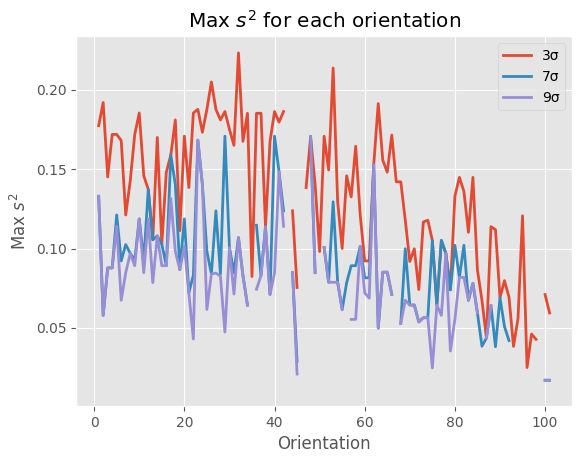

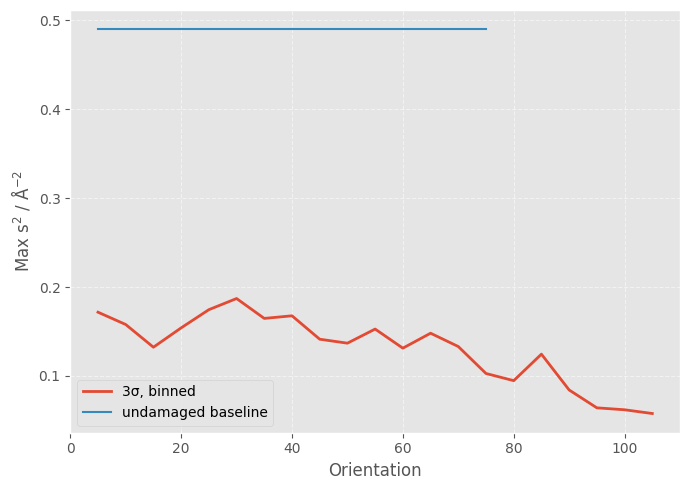

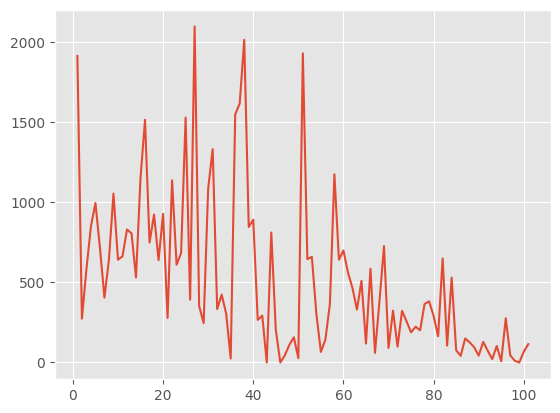

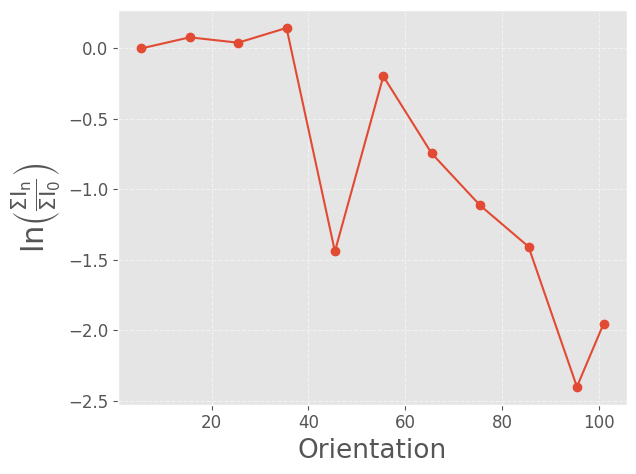


Annulus boundaries:
Annulus 1:
  s^2 : 0.000000  ->  0.058832
  g   : 0.000000   ->  0.485108
  d   : 2.061398   ->  inf

Annulus 2:
  s^2 : 0.058832  ->  0.096487
  g   : 0.485108   ->  0.621248
  d   : 1.609663   ->  2.061398

Annulus 3:
  s^2 : 0.096487  ->  0.223282
  g   : 0.621248   ->  0.945054
  d   : 1.058140   ->  1.609663



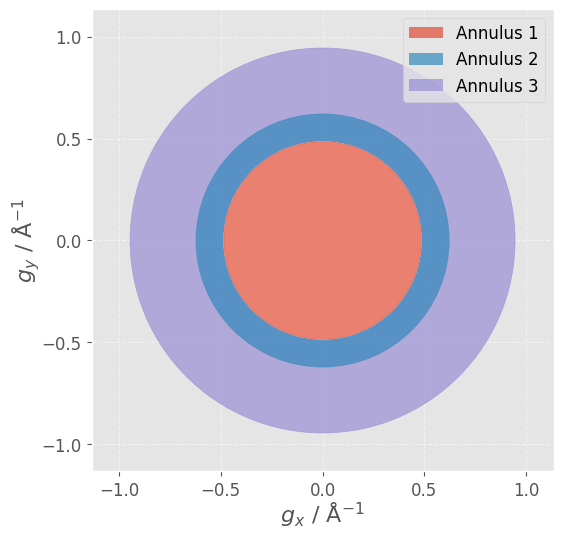

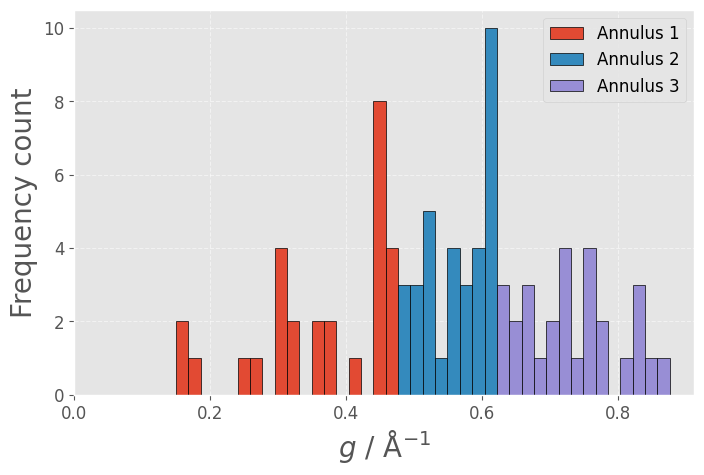

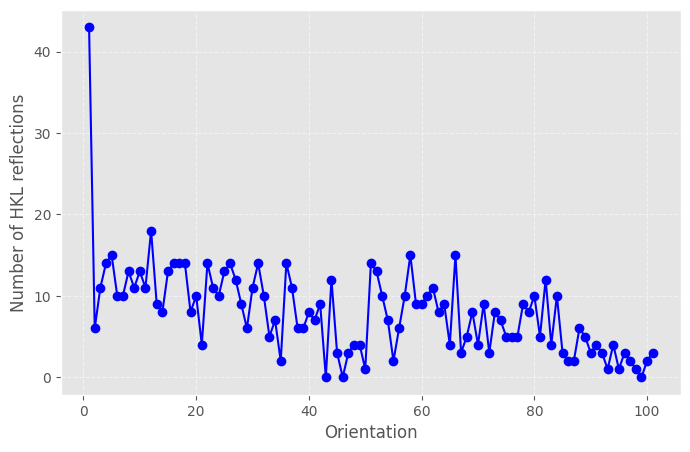


HKL counts per annulus for first orientation group (1-5):
Annulus 1: 30 hkls
Annulus 2: 29 hkls
Annulus 3: 30 hkls
Orientation group | Sum across annuli | Raw total HKLs | Match?
1-5            | 89                | 89             | ✅
6-10           | 57                | 57             | ✅
11-15           | 59                | 59             | ✅
16-20           | 60                | 60             | ✅
21-25           | 52                | 52             | ✅
26-30           | 52                | 52             | ✅
31-35           | 37                | 38             | ⚠️
36-40           | 45                | 45             | ✅
41-45           | 31                | 31             | ✅
46-50           | 12                | 12             | ✅
51-55           | 46                | 46             | ✅
56-60           | 49                | 49             | ✅
61-65           | 42                | 42             | ✅
66-70           | 35                | 35             | ✅
71-75           | 32   

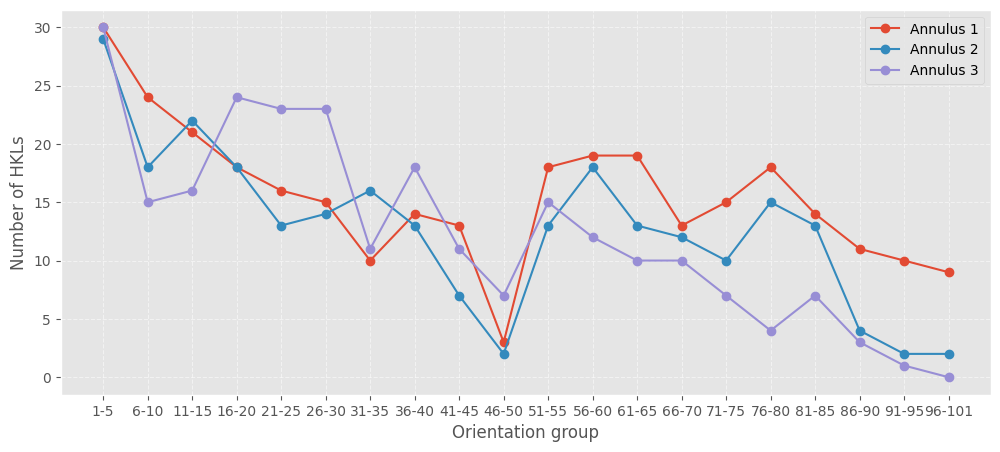

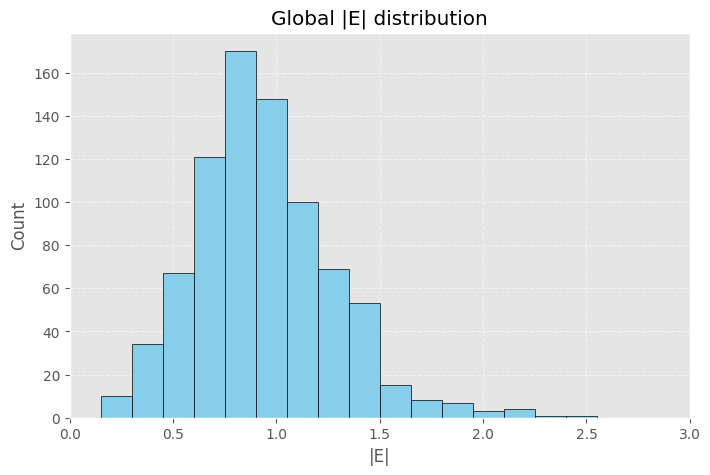

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Bin data based on g_mag (s^2) into annuli + group orientations
# Annuli boundaries are defined by equal-count quantiles using
# ONLY the first orientation group (1-5), then reused globally.
# ============================================================

# --- df_unique ---
g_mag = np.array(df_unique['g_mag'], dtype=float)
y = np.array(df_unique['lpcorrected_intensity'], dtype=float)
zone_id = np.array(df_unique['_refln_zone_axis_id'], dtype=int)
x = (g_mag / 2) ** 2  # s^2

# ------------------------------
# Plot max s^2 for each dataset
# ------------------------------
def plot_max_s2(df_in, label, linewidth=2):
    zone_id_tmp = np.array(df_in['_refln_zone_axis_id'], dtype=int)
    max_ori_tmp = int(np.max(zone_id_tmp))
    max_gmag = {}
    for ori in range(1, max_ori_tmp + 1):
        max_gmag[ori] = df_in.loc[df_in['_refln_zone_axis_id'] == ori, 'g_mag'].max()
    max_s2 = ((np.array(list(max_gmag.values())) / 2) ** 2)
    plt.plot(np.arange(1, max_ori_tmp + 1), max_s2, label=label, linewidth=linewidth)

plt.figure()
plot_max_s2(df_unique, "3σ")
plot_max_s2(df7_unique, "7σ")
plot_max_s2(df9_unique, "9σ")
plt.title('Max $s^2$ for each orientation')
plt.xlabel('Orientation')
plt.ylabel('Max $s^2$')
plt.legend()
plt.show()

# ------------------------------
# Plot binned max s^2 (e.g. ori 1–5, 6–10, ...)
# ------------------------------
def plot_binned_max_s2(df_in, label, bin_size=5, linewidth=2):
    zone_id_tmp = np.array(df_in['_refln_zone_axis_id'], dtype=int)
    max_ori_tmp = int(np.max(zone_id_tmp))

    # collect max g_mag per orientation
    max_gmag = []
    for ori in range(1, max_ori_tmp + 1):
        max_val = df_in.loc[df_in['_refln_zone_axis_id'] == ori, 'g_mag'].max()
        max_gmag.append(max_val)

    max_gmag = np.array(max_gmag)
    max_s2 = ((max_gmag / 2) ** 2)

    # split into orientation bins
    s2_split = np.array_split(max_s2, int(np.ceil(len(max_s2) / bin_size)))

    binned_s2 = np.array([np.nanmean(chunk) for chunk in s2_split])

    # x-axis shows real orientation numbers
    bin_centers = (np.arange(len(binned_s2)) * bin_size) + bin_size

    plt.plot(bin_centers, binned_s2, label=label, linewidth=linewidth)


plt.figure(figsize=(7,5))

plot_binned_max_s2(df_unique, "3σ, binned", bin_size=5)
#plot_binned_max_s2(df7_unique, "7σ, binned", bin_size=5)
#plot_binned_max_s2(df9_unique, "9σ, binned", bin_size=5)

plt.xlabel('Orientation')
plt.ylabel(r'Max $\mathrm{s^2}$ / $\mathrm{\AA^{-2}}$')
xaxisvalues=np.arange(5,76)
plt.plot(xaxisvalues,np.full_like(xaxisvalues,0.49, dtype=float), label='undamaged baseline')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save high-quality vector figure (perfect for Overleaf + PowerPoint)
plt.savefig("max_s2_orientationnosigma.pdf", bbox_inches="tight")

plt.show()

# ------------------------------
# Parameters
# ------------------------------
n_annuli = 3
ori_group = 5
E_hist_bins = np.linspace(0, 3, 21)

plot_orientation_distributions = False   # per annulus + per ori group
plot_annulus_combined = False            # per annulus (all orientations combined)
plot_orientation_combined = False        # NEW: all annuli combined, split by orientation group

# ------------------------------
# Total intensity per orientation
# ------------------------------
max_ori = int(np.max(zone_id))
total_intensities = {}
for ori in range(1, max_ori + 1):
    total_intensities[ori] = df_unique.loc[df_unique['_refln_zone_axis_id'] == ori,
                                           'lpcorrected_intensity'].sum()

totals = [total_intensities[ori] for ori in range(1, max_ori + 1)]
plt.plot(np.arange(1, max_ori + 1), totals)
plt.show()


# ------------------------------
# Average every 10 orientations
# ------------------------------
bin_size = 10
binned_totals = []
binned_orientations = []

for start in range(0, max_ori, bin_size):
    end = min(start + bin_size, max_ori)
    bin_values = totals[start:end]
    binned_totals.append(np.mean(bin_values))

    # midpoint orientation of the bin
    midpoint = (start + 1 + end) / 2
    binned_orientations.append(midpoint)

# ------------------------------
# Plot smoothed curve
# ------------------------------
plt.figure()
plt.plot(binned_orientations, np.log(binned_totals/binned_totals[0]), marker='o', label="mean total (10-bin)")
plt.xlabel("Orientation", size=19)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel(r"$\ln\!\left(\frac{\mathrm{\Sigma I_n}}{\mathrm{\Sigma I_0}}\right)$", size=22)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('SmoothedtotalIntensity_abir',dpi=600)
plt.show()

# ------------------------------
# Build orientation group starts
# ------------------------------
ori_start_list = list(range(1, max_ori + 1, ori_group))
if len(ori_start_list) >= 2:
    last_size = max_ori - ori_start_list[-1] + 1
    if last_size < ori_group:
        ori_start_list.pop(-1)

# ------------------------------
# Define annuli using first orientation group (equal-count quantiles)
# ------------------------------
first_ori_start = ori_start_list[0]
first_ori_end = min(first_ori_start + ori_group - 1, max_ori)

x_first_group = np.concatenate([x[zone_id == ori] for ori in range(first_ori_start, first_ori_end + 1)])
quantiles = np.linspace(0, 1, n_annuli + 1)
annulus_edges = np.quantile(x_first_group, quantiles)

# force first edge to 0 and last edge to max(x)
annulus_edges[0] = 0.0
annulus_edges[-1] = np.max(x)

start = {annuli: annulus_edges[annuli] for annuli in range(n_annuli)}
stop  = {annuli: annulus_edges[annuli + 1] for annuli in range(n_annuli)}

print("\nAnnulus boundaries:")
for annuli in range(n_annuli):
    s2_lo = start[annuli]
    s2_hi = stop[annuli]

    g_lo = 2 * np.sqrt(s2_lo)
    g_hi = 2 * np.sqrt(s2_hi)

    d_lo = 1 / g_hi if g_hi != 0 else np.inf   # high g → low d
    d_hi = 1 / g_lo if g_lo != 0 else np.inf   # low g → high d

    print(
        f"Annulus {annuli+1}:\n"
        f"  s^2 : {s2_lo:.6f}  ->  {s2_hi:.6f}\n"
        f"  g   : {g_lo:.6f}   ->  {g_hi:.6f}\n"
        f"  d   : {d_lo:.6f}   ->  {d_hi:.6f}\n"
    )


# ------------------------------
# Plot annuli in g-space
# ------------------------------
g_start = {ann: 2*np.sqrt(start[ann]) for ann in range(n_annuli)}
g_stop  = {ann: 2*np.sqrt(stop[ann])  for ann in range(n_annuli)}

fig, ax = plt.subplots(figsize=(6,6))
ax.set_aspect('equal')
g_max = 2 * np.sqrt(np.max(x))
ax.set_xlim(-g_max*1.2, g_max*1.2)
ax.set_ylim(-g_max*1.2, g_max*1.2)

# Draw outermost annulus first so others appear on top
for ann in reversed(range(n_annuli)):
    outer = g_stop[ann]
    inner = g_start[ann]

    if ann == 0:
        circle = plt.Circle((0,0), outer, color=colors[ann], alpha=0.7, zorder=3)
        ax.add_patch(circle)
    elif ann == n_annuli-1:
        circle = plt.Circle((0,0), outer, color=colors[ann], alpha=0.7, zorder=1)
        ax.add_patch(circle)
    else:
        ring = plt.Circle((0,0), outer, color=colors[ann], alpha=0.7, zorder=2)
        ax.add_patch(ring)
        inner_cutout = plt.Circle((0,0), inner, color='white', alpha=1, zorder=3)
        ax.add_patch(inner_cutout)

ax.set_xlabel(r'$g_x\ /\ \mathrm{\AA^{-1}}$', size=16, labelpad=0)
ax.set_ylabel(r'$g_y\ /\ \mathrm{\AA^{-1}}$', size=16, labelpad=0)

# ---- Legend built from proxy handles ----
from matplotlib.patches import Patch
handles = [Patch(facecolor=colors[ann], edgecolor='none', alpha=0.7,
                 label=f"Annulus {ann+1}") for ann in range(n_annuli)]
ax.legend(handles=handles, loc='upper right', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig("annulus_g.pdf", bbox_inches="tight")
plt.show()

# ------------------------------
# Frequency vs g (NO overlap, orientations 1–5 only)
# ------------------------------

# Mask only orientations 1–5
mask_15 = (zone_id >= first_ori_start) & (zone_id <= first_ori_end)
g_values = g_mag[mask_15]

# Histogram
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

n_bins = 40
counts, edges = np.histogram(g_values, bins=n_bins)

bin_centres = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]

plt.figure(figsize=(8,5))

for i in range(len(counts)):
    g_mid = bin_centres[i]
    count = counts[i]

    # Assign colour by annulus
    for ann in range(n_annuli):
        if g_start[ann] <= g_mid <= g_stop[ann]:
            bar_color = colors[ann]
            break

    plt.bar(g_mid,
            count,
            width=bin_width,
            color=bar_color,
            edgecolor='black',
            align='center')

# ✅ Create proxy legend handles
legend_handles = [
    Patch(facecolor=colors[ann], edgecolor='black',
          label=f"Annulus {ann+1}")
    for ann in range(n_annuli)
]

plt.xlabel('$g\ /\ \mathrm{\\AA^{-1}}$', size=20)
plt.ylabel("Frequency count", size=20)
plt.legend(handles=legend_handles, fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(0)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig("frequency_g.pdf", bbox_inches="tight")
plt.show()


# ------------------------------
# Total HKL counts per orientation (no annuli)
# ------------------------------
max_ori = int(np.max(zone_id))
hkl_counts = [np.sum(zone_id == ori) for ori in range(1, max_ori + 1)]

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, max_ori + 1), hkl_counts, marker='o', linestyle='-', color='blue')
plt.xlabel("Orientation")
plt.ylabel("Number of HKL reflections")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



# ------------------------------
# HKL counts per annulus (first orientation group)
# ------------------------------
print("\nHKL counts per annulus for first orientation group (1-5):")
for annuli in range(n_annuli):
    count = sum(np.sum((x[zone_id == ori] > start[annuli]) & (x[zone_id == ori] < stop[annuli]))
                for ori in range(first_ori_start, first_ori_end + 1))
    print(f"Annulus {annuli+1}: {count} hkls")

# ------------------------------
# Storage dicts
# ------------------------------
E_all = {annuli: [] for annuli in range(n_annuli)}
y_all = {annuli: [] for annuli in range(n_annuli)}
x_all = {annuli: [] for annuli in range(n_annuli)}
ymean = {annuli: [] for annuli in range(n_annuli)}
E_by_group = {annuli: {} for annuli in range(n_annuli)}

# ------------------------------
# Main loop: annuli + orientation groups
# ------------------------------
for annuli in range(n_annuli):
    start_val = start[annuli]
    stop_val  = stop[annuli]
    for ori_start in ori_start_list:
        ori_end = max_ori if ori_start == ori_start_list[-1] else ori_start + ori_group - 1
        ycat, xcat = [], []
        for ori in range(ori_start, ori_end + 1):
            xori = x[zone_id == ori]
            yori = y[zone_id == ori]
            mask = (xori > start_val) & (xori < stop_val)
            ycat.append(yori[mask])
            xcat.append(xori[mask])
        if not ycat: continue
        ycat = np.concatenate(ycat)
        xcat = np.concatenate(xcat)
        if len(ycat) == 0: continue
        mean_y = np.mean(ycat)
        ymean[annuli].append(mean_y)
        E = np.sqrt(ycat / mean_y)
        E_all[annuli].extend(E)
        y_all[annuli].extend(ycat)
        x_all[annuli].extend(xcat)
        group_key = f"{ori_start}-{ori_end}"
        if group_key not in E_by_group[annuli]:
            E_by_group[annuli][group_key] = []
        E_by_group[annuli][group_key].extend(E)

# ------------------------------
# Plot combined histograms per annulus (optional)
# ------------------------------
if plot_annulus_combined:
    for annuli in range(n_annuli):
        Evals = np.array(E_all[annuli])
        Evals = Evals[Evals < 3]
        plt.figure(figsize=(8,5))
        plt.hist(Evals, bins=E_hist_bins, color="skyblue", edgecolor="black")
        plt.text(0.55, 0.85,
                 f"annulus in d_hkl of {1/(2*np.sqrt(stop[annuli])):.1f} to {1/(2*np.sqrt(start[annuli])):.1f}",
                 transform=plt.gca().transAxes)
        plt.xlabel("|E|")
        plt.ylabel("Count")
        plt.title(f"Histogram of |E| for annulus {annuli+1} (combined)")
        plt.xlim(0,3)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()


# ------------------------------
# Plot separate histograms per annulus and orientation-group (optional)
# ------------------------------
if plot_orientation_distributions:
    for annuli in range(n_annuli):
        for group_key, Elist in E_by_group[annuli].items():
            Evals = np.array(Elist)
            Evals = Evals[Evals < 3]
            if len(Evals) == 0:
                continue
            plt.figure(figsize=(8,5))
            plt.hist(Evals, bins=E_hist_bins, color="skyblue", edgecolor="black")
            plt.text(0.55, 0.85,
                     f"annulus in d_hkl of {1/(2*np.sqrt(stop[annuli])):.1f} to {1/(2*np.sqrt(start[annuli])):.1f}",
                     transform=plt.gca().transAxes)
            plt.xlabel("|E|")
            plt.ylabel("Count")
            plt.title(f"|E| Histogram (annulus {annuli+1}, orientations {group_key})")
            plt.xlim(0,3)
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.show()

# ------------------------------
# HKL counts per orientation group and annulus
# ------------------------------
group_labels = []
annulus_counts = {ann: [] for ann in range(n_annuli)}

for ori_start in ori_start_list:
    ori_end = max_ori if ori_start == ori_start_list[-1] else ori_start + ori_group - 1
    group_labels.append(f"{ori_start}-{ori_end}")
    for ann in range(n_annuli):
        count = sum(np.sum((x[zone_id == ori] > start[ann]) & (x[zone_id == ori] < stop[ann]))
                    for ori in range(ori_start, ori_end + 1))
        annulus_counts[ann].append(count)
# ------------------------------
# Test: compare HKL counts per orientation group vs sum across annuli
# ------------------------------

print("Orientation group | Sum across annuli | Raw total HKLs | Match?")

for i, ori_start in enumerate(ori_start_list):
    ori_end = max_ori if ori_start == ori_start_list[-1] else ori_start + ori_group - 1

    # Sum HKLs across all annuli for this group
    annuli_sum = sum(
        np.sum((x[zone_id == ori] > start[ann]) & (x[zone_id == ori] < stop[ann]))
        for ann in range(n_annuli)
        for ori in range(ori_start, ori_end + 1)
    )

    # Raw HKLs for this orientation group
    raw_total = np.sum((zone_id >= ori_start) & (zone_id <= ori_end))

    # Print comparison
    match = "✅" if annuli_sum == raw_total else "⚠️"
    print(f"{ori_start}-{ori_end:<12} | {annuli_sum:<17} | {raw_total:<14} | {match}")

    # ------------------------------
# Plot HKL counts per annulus as a function of orientation group
# ------------------------------
plt.figure(figsize=(12,5))

for ann in range(n_annuli):
    plt.plot(group_labels, annulus_counts[ann], marker='o', color=colors[ann], label=f"Annulus {ann+1}")

plt.xlabel("Orientation group")
plt.ylabel("Number of HKLs")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("hkl_counts_per_group.pdf", bbox_inches="tight")
plt.show()

# ------------------------------
# Global |E| distribution (all annuli combined)
# ------------------------------
E_global = np.concatenate([np.array(E_all[ann]) for ann in range(n_annuli)])
E_global = E_global[E_global < 3]   # same cutoff as before

plt.figure(figsize=(8,5))
plt.hist(E_global, bins=E_hist_bins, color="skyblue", edgecolor="black")
plt.xlabel("|E|")
plt.ylabel("Count")
plt.title("Global |E| distribution")
plt.xlim(0,3)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ------------------------------
# All annuli combined, split by orientation group (optional)
# ------------------------------
if plot_orientation_combined:

    for ori_start in ori_start_list:

        ori_end = max_ori if ori_start == ori_start_list[-1] else ori_start + ori_group - 1

        ycat = []

        for ori in range(ori_start, ori_end + 1):
            yori = y[zone_id == ori]
            ycat.append(yori)

        if not ycat:
            continue

        ycat = np.concatenate(ycat)

        if len(ycat) == 0:
            continue

        mean_y = np.mean(ycat)
        Evals = np.sqrt(ycat / mean_y)
        Evals = Evals[Evals < 3]

        plt.figure(figsize=(8,5))
        plt.hist(Evals, bins=E_hist_bins, edgecolor="black", density=True, label=f"Orientations {ori_start}-{ori_end}")
        plt.xlabel("|E|", size=16)
        plt.ylabel("Count Density", size=16)
        plt.xlim(0,3)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.xticks(size=16)
        plt.yticks(size=16)
        plt.legend(fontsize=16)
        plt.savefig(f"|E| distribution (orientations) {ori_start}-{ori_end}.png", dpi=600)
        plt.show()


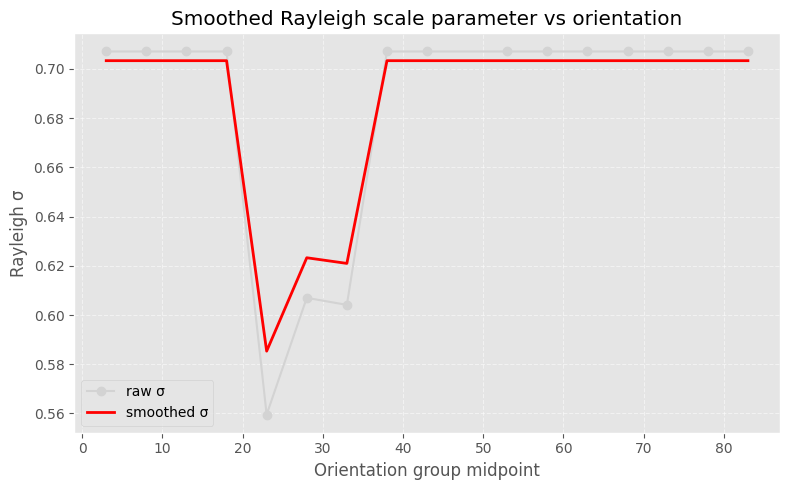

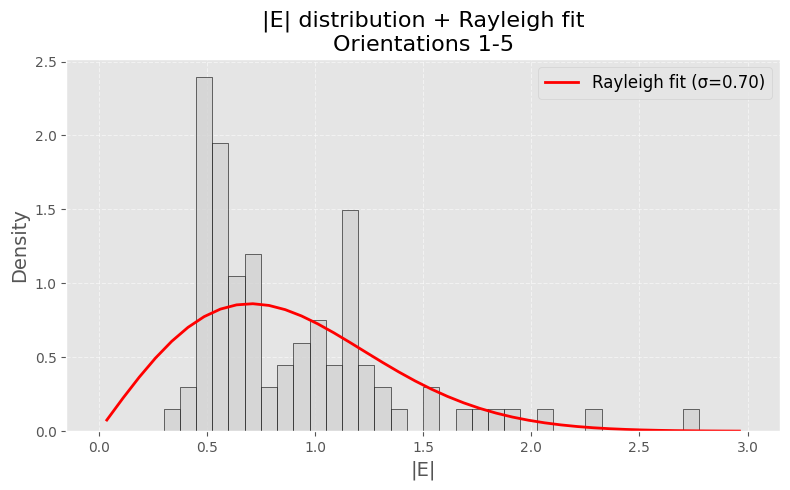

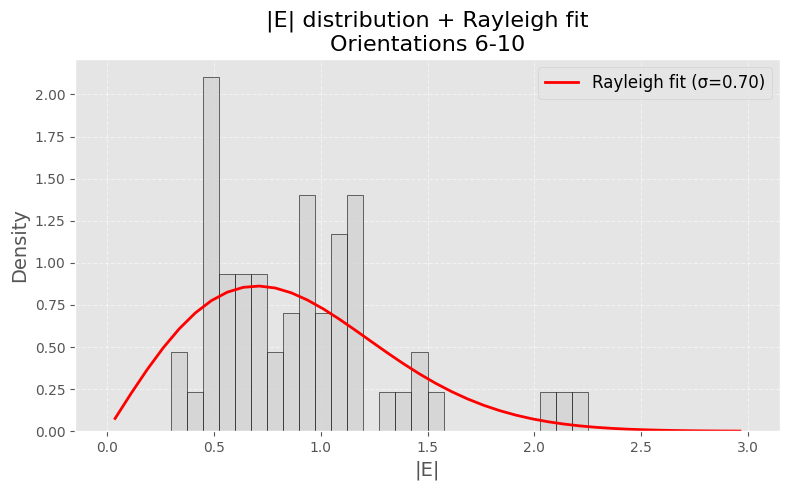

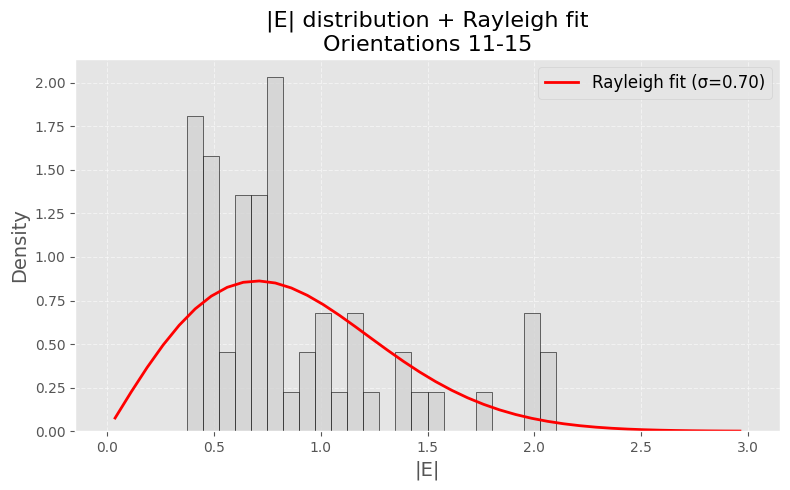

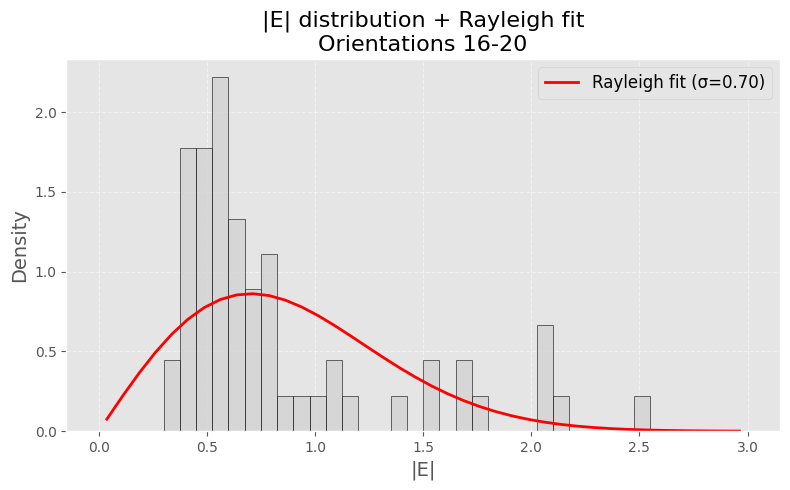

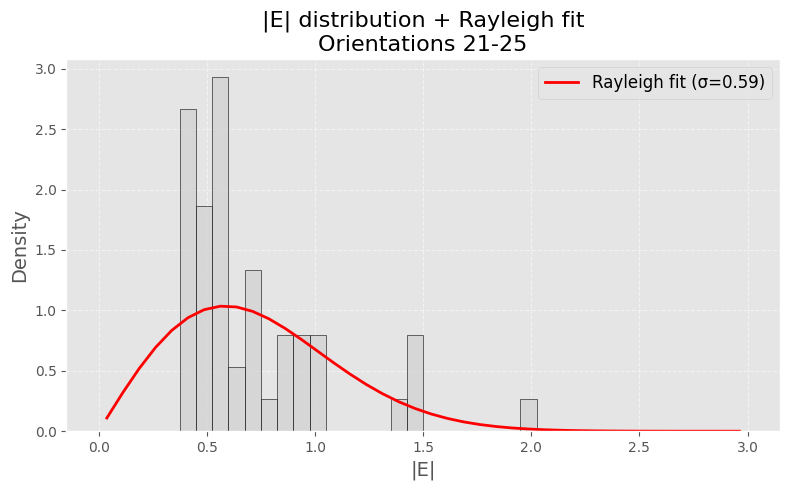

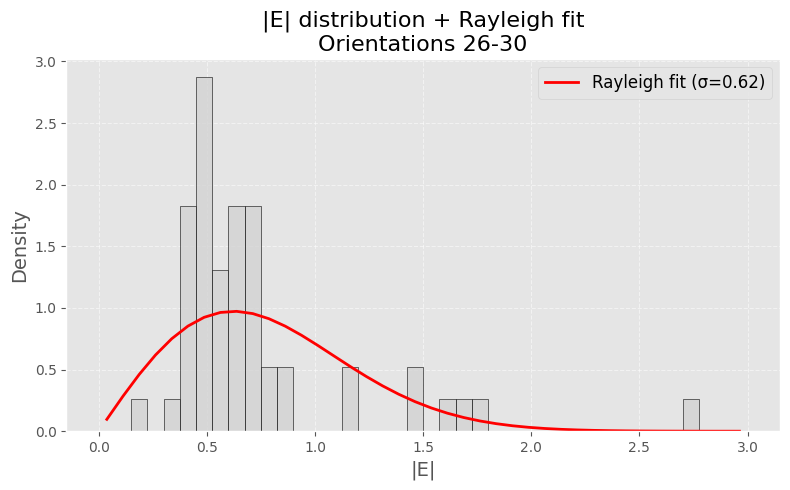

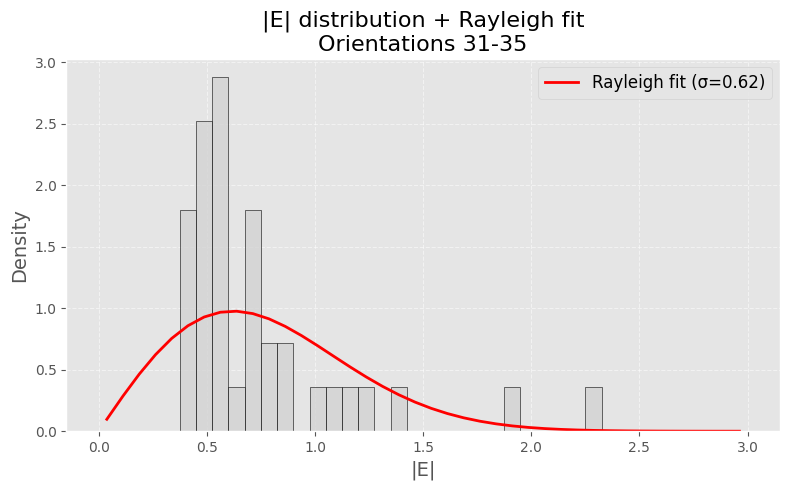

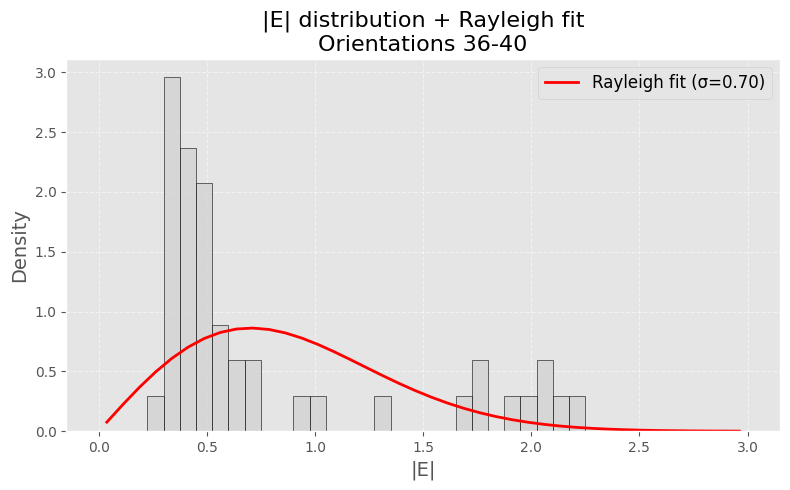

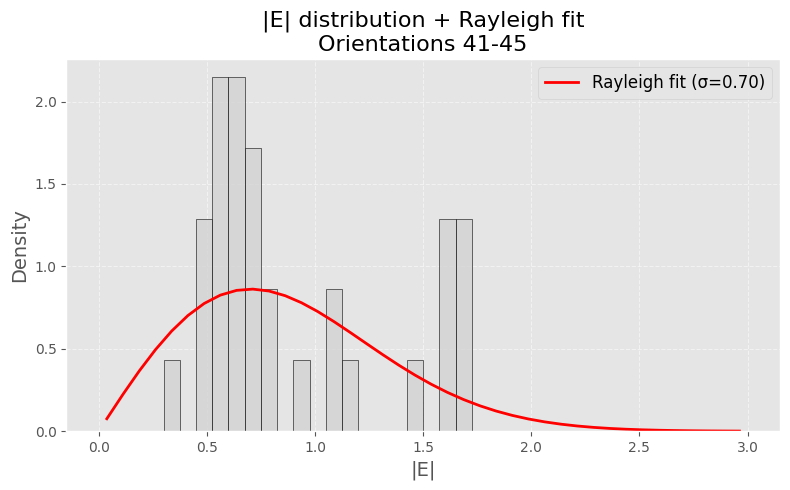

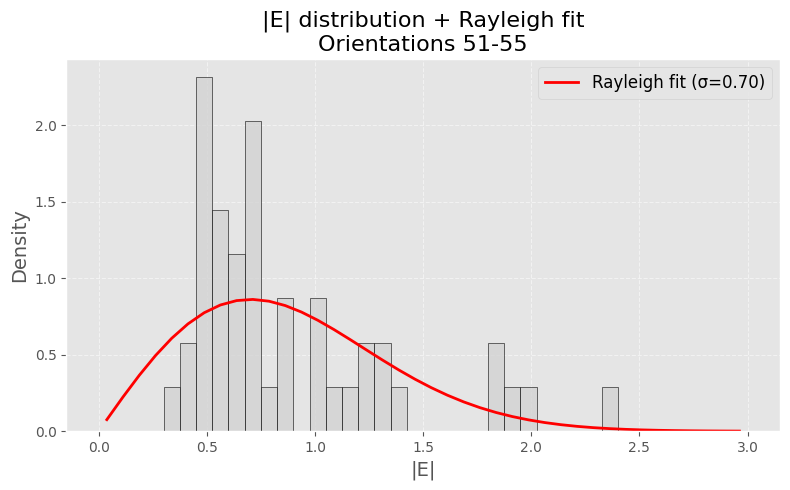

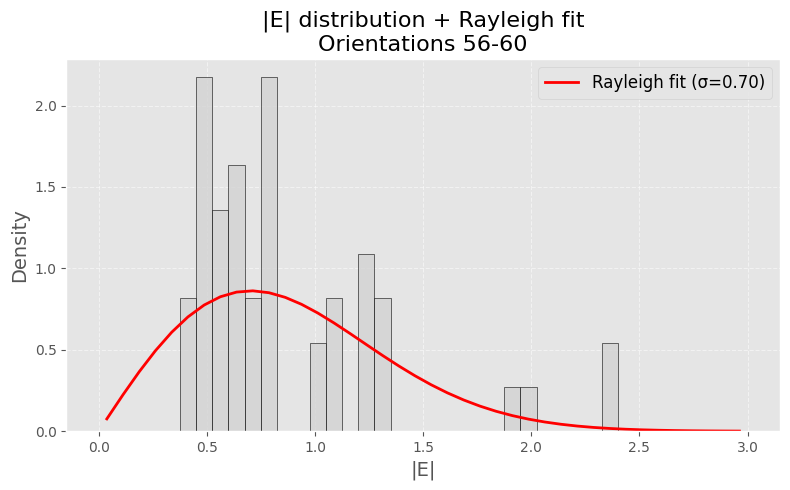

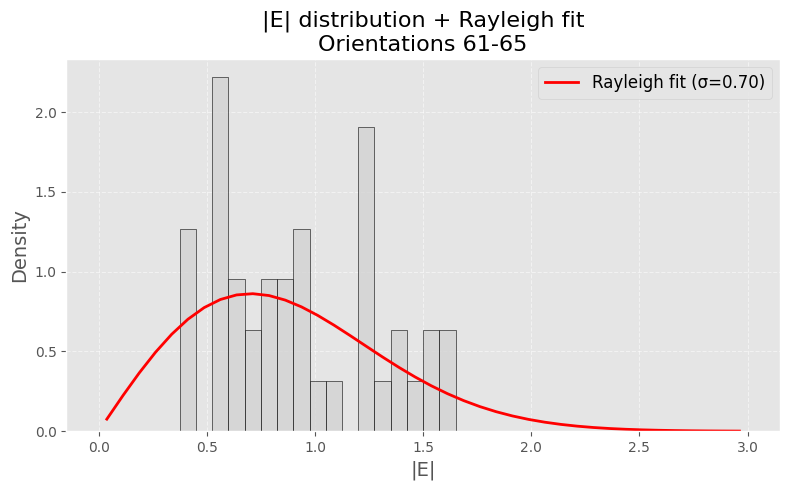

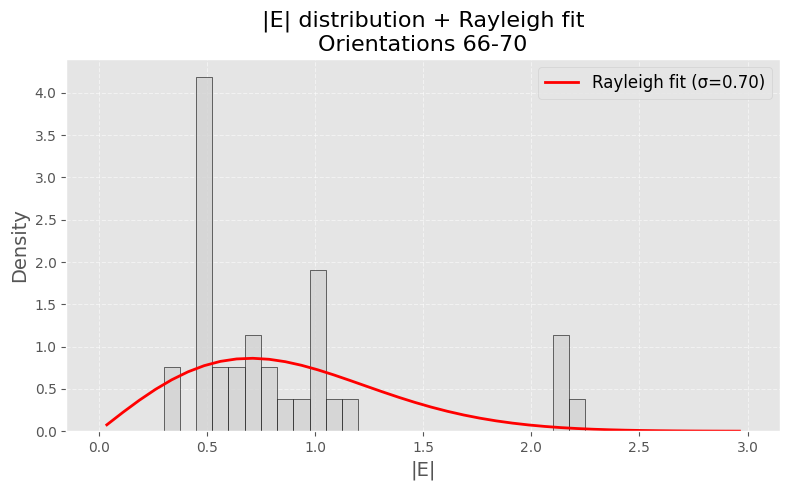

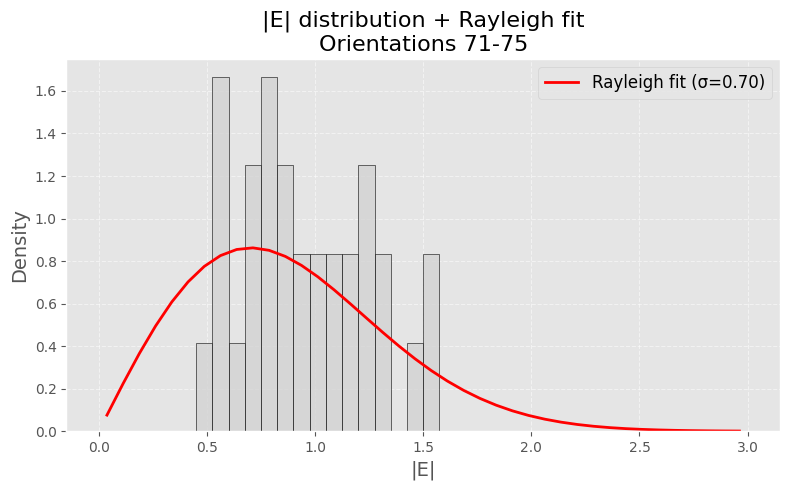

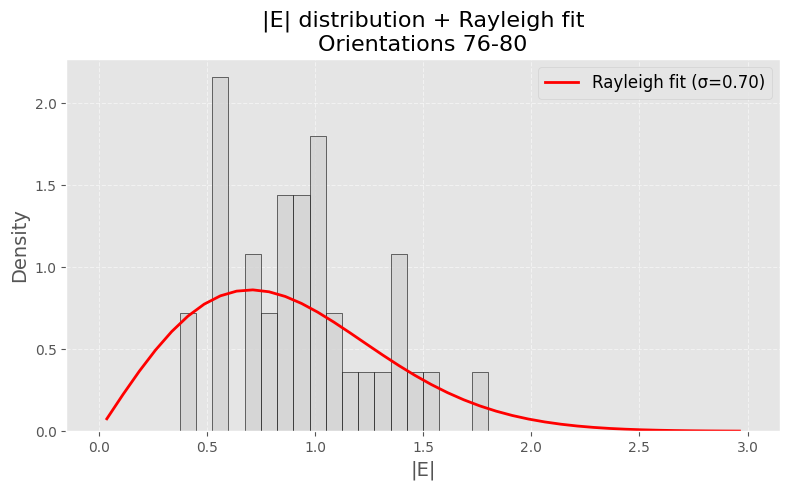

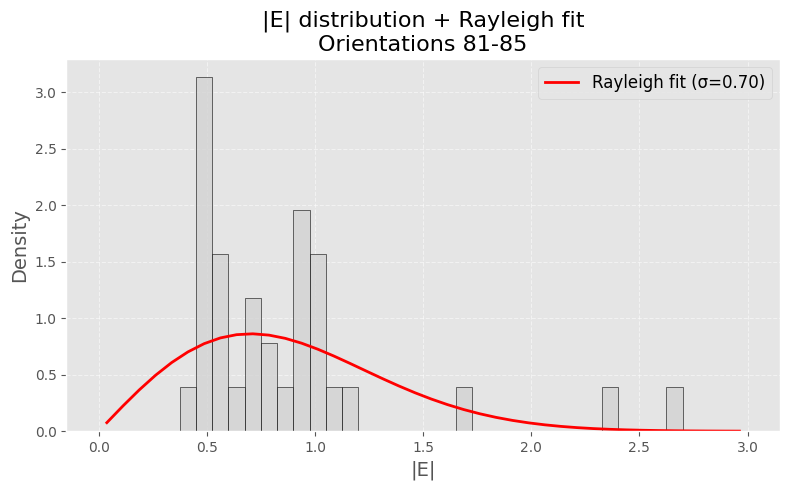

In [ ]:
# ============================================================
# Rayleigh fits of |E| distributions for orientation groups
# with shrinkage smoothing of σ
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# ------------------------------------------------------------
# 1. Extract |E| values for each orientation group
# ------------------------------------------------------------
E_groups = {}
group_midpoints = []

for ori_start in ori_start_list:
    ori_end = max_ori if ori_start == ori_start_list[-1] else ori_start + ori_group - 1
    group_midpoints.append(0.5 * (ori_start + ori_end))

    ycat = [y[zone_id == ori] for ori in range(ori_start, ori_end + 1)]
    ycat = np.concatenate(ycat) if len(ycat) > 0 else np.array([])

    if len(ycat) == 0:
        E_groups[f"{ori_start}-{ori_end}"] = np.array([])
        continue

    mean_y = np.mean(ycat)
    Evals = np.sqrt(ycat / mean_y)
    Evals = Evals[Evals < 3]

    E_groups[f"{ori_start}-{ori_end}"] = Evals

# ------------------------------------------------------------
# 2. Global Rayleigh scale σ_global
# ------------------------------------------------------------
E_all_global = np.concatenate([vals for vals in E_groups.values() if len(vals) > 0])
# Rayleigh MLE: fix loc=0
sigma_global = rayleigh.fit(E_all_global, floc=0)[1]

# ------------------------------------------------------------
# 3. Fit each group + shrinkage smoothing
# ------------------------------------------------------------
sigma_raw = []
sigma_smooth = []
valid_labels = []

lambda_shrink = 0.20   # smoothing strength

for label, Evals in E_groups.items():
    if len(Evals) < 20:
        continue

    # Fit Rayleigh (σ only)
    _, sigma_raw_i = rayleigh.fit(Evals, floc=0)

    # Smooth via shrinkage
    sigma_smoothed = (1 - lambda_shrink) * sigma_raw_i + lambda_shrink * sigma_global

    valid_labels.append(label)
    sigma_raw.append(sigma_raw_i)
    sigma_smooth.append(sigma_smoothed)

sigma_raw = np.array(sigma_raw)
sigma_smooth = np.array(sigma_smooth)

xvals = [np.mean(list(map(int, lbl.split('-')))) for lbl in valid_labels]

# ------------------------------------------------------------
# 4. Plot raw vs smoothed σ
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(xvals, sigma_raw, 'o-', color='lightgray', label="raw σ")
plt.plot(xvals, sigma_smooth, 'r-', linewidth=2, label="smoothed σ")
plt.xlabel("Orientation group midpoint")
plt.ylabel("Rayleigh σ")
plt.title("Smoothed Rayleigh scale parameter vs orientation")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("rayleigh_sigma_smooth.pdf")
plt.show()

# ------------------------------------------------------------
# 5. Histogram + smoothed Rayleigh fit
# ------------------------------------------------------------
E_bins = np.linspace(0, 3, 41)
bin_centres = 0.5 * (E_bins[:-1] + E_bins[1:])

for label, Evals in E_groups.items():
    if len(Evals) < 20:
        continue

    idx = valid_labels.index(label)
    sigma_fit = sigma_smooth[idx]

    # histogram
    counts, edges = np.histogram(Evals, bins=E_bins, density=True)

    # Rayleigh PDF
    pdf_vals = rayleigh.pdf(bin_centres, loc=0, scale=sigma_fit)

    plt.figure(figsize=(8,5))
    plt.bar(bin_centres, counts, width=edges[1]-edges[0],
            color='lightgray', edgecolor='black', alpha=0.8)

    plt.plot(bin_centres, pdf_vals, 'r-', linewidth=2,
             label=f"Rayleigh fit (σ={sigma_fit:.2f})")

    plt.xlabel("|E|", size=14)
    plt.ylabel("Density", size=14)
    plt.title(f"|E| distribution + Rayleigh fit\nOrientations {label}", size=16)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)
    plt.tight_layout()

    safe_label = label.replace("-", "_")
    plt.savefig(f"rayleigh_fit_hist_{safe_label}.pdf")
    plt.show()


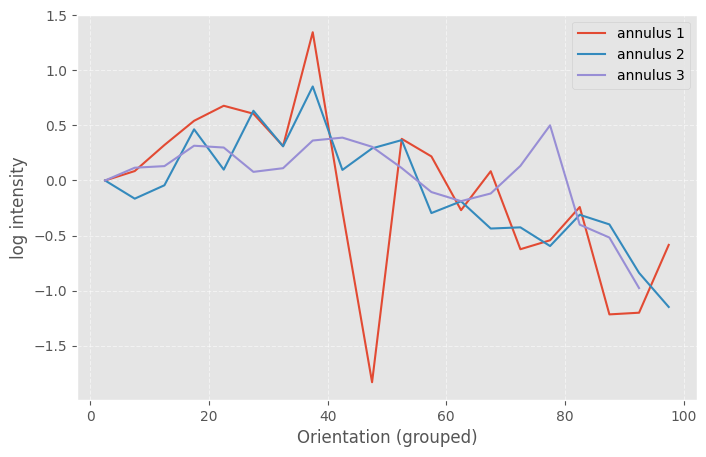

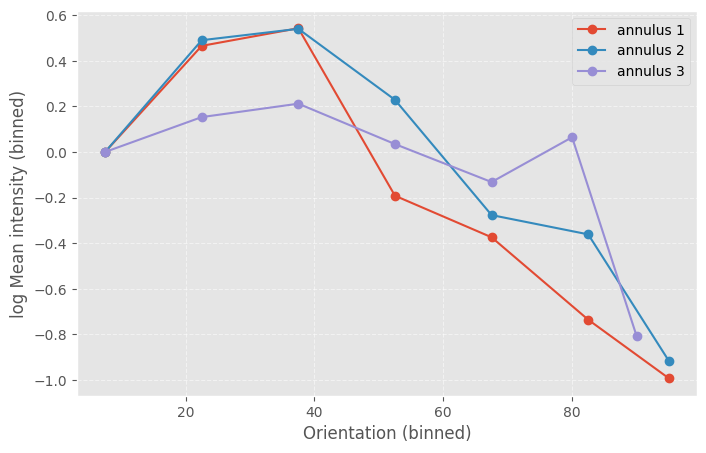

In [ ]:
# ============================
# Plot log(ymean/y0) vs grouped orientation
# ============================

plt.figure(figsize=(8, 5))

for annuli in range(n_annuli):

    yvals = np.array(ymean[annuli])

    if len(yvals) == 0 or yvals[0] == 0:
        continue

    # x-axis = midpoint orientation of each ori_group chunk
    xaxis = np.arange(len(yvals)) * ori_group + (ori_group / 2)

    plt.plot(xaxis, np.log(yvals / yvals[0]), label=f'annulus {annuli+1}')

plt.legend()
plt.xlabel("Orientation (grouped)")
plt.ylabel("log intensity")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# ============================
# Reduce grouped ymean into EXACTLY N points
# ============================

target_points = 7   # <-- you want ~4 final averaged points

plt.figure(figsize=(8, 5))

for annuli in range(n_annuli):

    yvals = np.array(ymean[annuli], dtype=float)

    # remove nan
    yvals = yvals[~np.isnan(yvals)]

    if len(yvals) < 2 or yvals[0] == 0:
        continue

    # x positions for original grouped points
    xvals = np.arange(len(yvals)) * ori_group + (ori_group / 2)

    # split into target_points chunks
    xsplit = np.array_split(xvals, target_points)
    ysplit = np.array_split(yvals, target_points)

    x_binned = np.array([np.mean(xx) for xx in xsplit if len(xx) > 0])
    y_binned = np.array([np.mean(yy) for yy in ysplit if len(yy) > 0])

    plt.plot(x_binned, np.log(y_binned / y_binned[0]), marker="o",
             label=f"annulus {annuli+1}")

plt.legend()
plt.xlabel("Orientation (binned)")
plt.ylabel("log Mean intensity (binned)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


<Figure size 640x480 with 0 Axes>

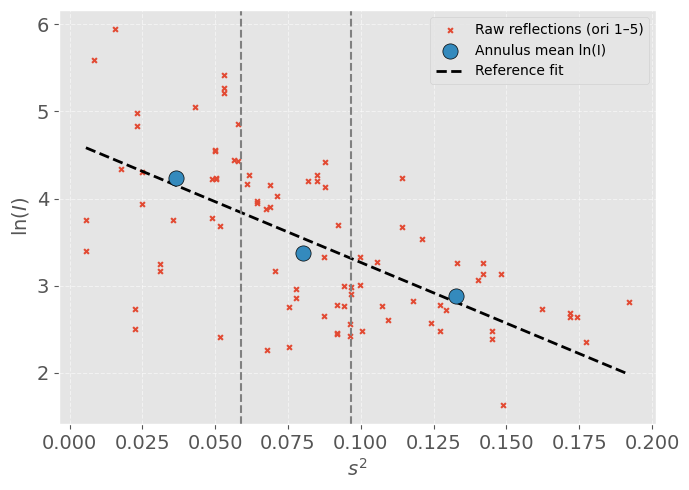

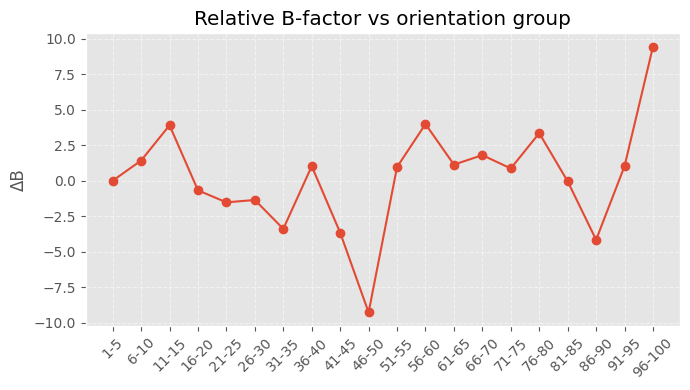


ΔB values:
1-5 1.1497486493788496e-15
6-10 1.4198808300058583
11-15 3.9011570356903547
16-20 -0.6779543580193883
21-25 -1.5237817986070408
26-30 -1.3562583881304564
31-35 -3.391049672920548
36-40 1.0233512039638262
41-45 -3.6554225971067296
46-50 -9.273998028648256
51-55 0.9613883402132866
56-60 3.989043536503391
61-65 1.1345519933084305
66-70 1.7994051468943848
71-75 0.864299404319297
76-80 3.3474880050677207
81-85 -0.0449650994508152
86-90 -4.160896424980243
91-95 1.0256689460054806
96-100 9.440061935002417


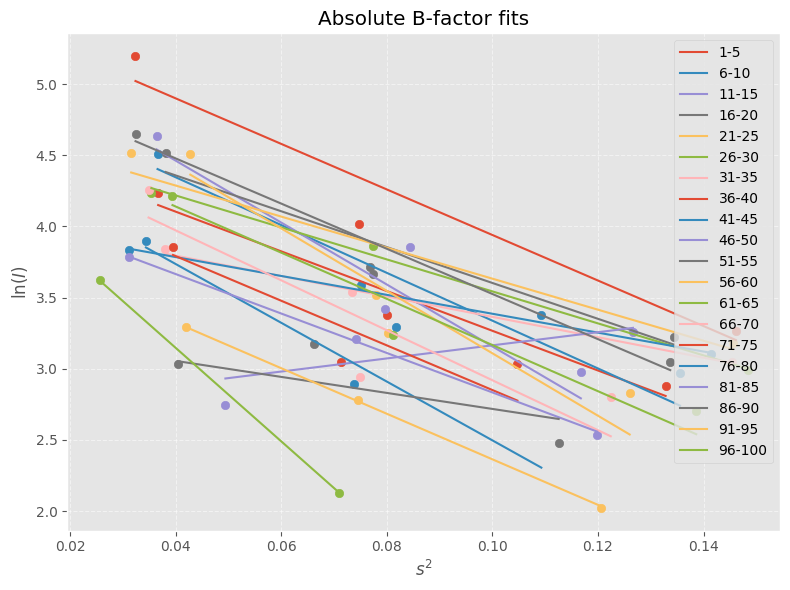


Absolute B values:
1-5 6.9723313261931
6-10 8.392212156198962
11-15 10.873488361883478
16-20 6.294376968173703
21-25 5.448549527586051
26-30 5.616072938062653
31-35 3.581281653272549
36-40 7.995682530156933
41-45 3.316908729086375
46-50 -2.3016667024551514
51-55 7.933719666406395
56-60 10.961374862696502
61-65 8.106883319501534
66-70 8.7717364730875
71-75 7.8366307305123675
76-80 10.319819331260822
81-85 6.927366226742292
86-90 2.811434901212859
91-95 7.998000272198593
96-100 16.412393261195525


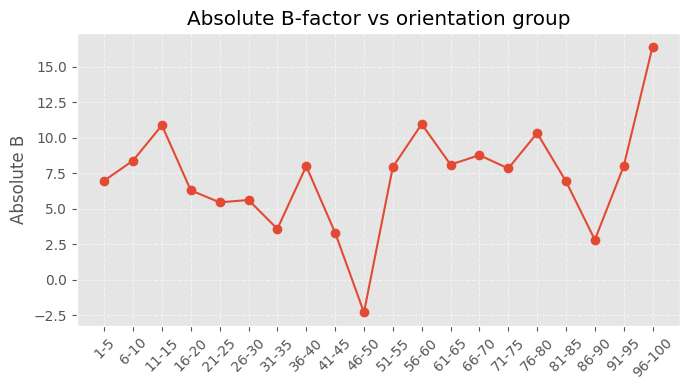

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
g_mag = np.array(df_unique['g_mag'], dtype=float)
y = np.array(df_unique['lpcorrected_intensity'], dtype=float)
zone_id = np.array(df_unique['_refln_zone_axis_id'], dtype=int)

x = (g_mag / 2)**2  # s²
max_ori = int(np.max(zone_id))

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
n_annuli = 3
ori_group = 5

# ------------------------------------------------------------
# Build orientation groups
# ------------------------------------------------------------
ori_start_list = list(range(1, max_ori + 1, ori_group))
if len(ori_start_list) >= 2 and max_ori - ori_start_list[-1] + 1 < ori_group:
    ori_start_list.pop(-1)

orientation_ranges = [(start, min(start + ori_group - 1, max_ori))
                      for start in ori_start_list]

# ------------------------------------------------------------
# Define annuli from first orientation group
# ------------------------------------------------------------
first_start, first_end = orientation_ranges[0]
x_first = np.concatenate([x[zone_id == ori] for ori in range(first_start, first_end + 1)])

quantiles = np.linspace(0, 1, n_annuli + 1)
annulus_edges = np.quantile(x_first, quantiles)
annulus_edges[0] = 0.0
annulus_edges[-1] = np.max(x)

# ------------------------------------------------------------
# Bin statistics (LOG-AVERAGED INTENSITIES)
# ------------------------------------------------------------
mean_lnI = {}
mean_s2 = {}
counts = {}

for start, end in orientation_ranges:
    key = f"{start}-{end}"
    mean_lnI[key] = []
    mean_s2[key] = []
    counts[key] = []

    for i in range(n_annuli):
        lo, hi = annulus_edges[i], annulus_edges[i + 1]

        ycat, xcat = [], []
        for ori in range(start, end + 1):
            mask = (zone_id == ori) & (x > lo) & (x <= hi)
            ycat.append(y[mask])
            xcat.append(x[mask])

        ycat = np.concatenate(ycat)
        xcat = np.concatenate(xcat)

        if len(ycat) == 0:
            mean_lnI[key].append(np.nan)
            mean_s2[key].append(np.nan)
            counts[key].append(0)
        else:
            # Corrected statistical estimator: mean(log(I))
            lnI_vals = np.log(ycat)
            mean_lnI[key].append(np.mean(lnI_vals))
            mean_s2[key].append(np.mean(xcat))
            counts[key].append(len(ycat))

    mean_lnI[key] = np.array(mean_lnI[key])
    mean_s2[key] = np.array(mean_s2[key])
    counts[key] = np.array(counts[key])

# ------------------------------------------------------------
# Reference fit for ΔB
# ------------------------------------------------------------
plt.figure()
B_values_relative = {}

ref_key = list(mean_lnI.keys())[0]
lnI_ref = mean_lnI[ref_key]
s2_ref = mean_s2[ref_key]

good = ~np.isnan(lnI_ref)
lnI_ref = lnI_ref[good]
s2_ref = s2_ref[good]
w_ref = counts[ref_key][good]

y0slope, y0intercept = np.polyfit(s2_ref, lnI_ref, 1, w=w_ref)

# ------------------------------------------------------------
# Demonstration plot for first orientation group
# ------------------------------------------------------------

first_key = ref_key
mask = np.isin(zone_id, np.arange(first_start, first_end + 1))
s2_raw = x[mask]
lnI_raw = np.log(y[mask])

s2_ann = s2_ref
lnI_ann = lnI_ref

xf = np.linspace(np.min(s2_raw), np.max(s2_raw), 300)
ref_line = y0slope * xf + y0intercept

plt.figure(figsize=(7,5))
plt.scatter(s2_raw, lnI_raw, s=12, marker='x',
            label="Raw reflections (ori 1–5)")

plt.scatter(s2_ann, lnI_ann, s=120, edgecolor='black',
            label="Annulus mean ln(I)", zorder=4)

plt.plot(xf, ref_line, 'k--', lw=2, label="Reference fit")

for boundary in annulus_edges[1:-1]:
    plt.axvline(boundary, color='gray', linestyle='--')

plt.xlabel(r"$s^2$", size=14)
plt.ylabel(r"$\ln(I)$", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("annulus_means15.pdf", dpi=600)
plt.show()

# ------------------------------------------------------------
# Compute ΔB
# ------------------------------------------------------------
for key in mean_lnI:
    lnIvals = mean_lnI[key]
    s2_vals = mean_s2[key]
    good = ~np.isnan(lnIvals)
    if np.sum(good) < 2:
        continue

    lnIvals = lnIvals[good]
    s2_vals = s2_vals[good]
    w = counts[key][good]

    yvals = lnIvals - (y0slope * s2_vals + y0intercept)

    slope, intercept = np.polyfit(s2_vals, yvals, 1, w=w)
    B_rel = -slope / 2
    B_values_relative[key] = B_rel

plt.figure(figsize=(7,4))
keys = list(B_values_relative.keys())
vals = [B_values_relative[k] for k in keys]

plt.plot(vals, marker='o')
plt.xticks(range(len(keys)), keys, rotation=45)
plt.ylabel("ΔB")
plt.title("Relative B-factor vs orientation group")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("B_relative.pdf", dpi=600)
plt.show()

print("\nΔB values:")
for k,v in B_values_relative.items():
    print(k, v)

# ------------------------------------------------------------
# Absolute B-factors
# ------------------------------------------------------------
B_values_absolute = {}

plt.figure(figsize=(8,6))

for key in mean_lnI:
    lnIvals = mean_lnI[key]
    s2_vals = mean_s2[key]
    wvals = counts[key]

    good = ~np.isnan(lnIvals)
    if np.sum(good) < 2:
        continue

    lnIvals = lnIvals[good]
    s2_vals = s2_vals[good]
    wvals = wvals[good]

    slope, intercept = np.polyfit(s2_vals, lnIvals, 1, w=wvals)
    B_abs = -0.5 * slope
    B_values_absolute[key] = B_abs

    xf = np.linspace(np.min(s2_vals), np.max(s2_vals), 200)
    plt.scatter(s2_vals, lnIvals)
    plt.plot(xf, slope*xf + intercept, label=f"{key}")

plt.xlabel(r"$s^2$")
plt.ylabel(r"$\ln(I)$")
plt.title("Absolute B-factor fits")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nAbsolute B values:")
for k,v in B_values_absolute.items():
    print(k, v)

# ------------------------------------------------------------
# Plot absolute B vs group
# ------------------------------------------------------------
plt.figure(figsize=(7,4))
keys = list(B_values_absolute.keys())
vals = [B_values_absolute[k] for k in keys]

plt.plot(vals, marker='o')
plt.xticks(range(len(keys)), keys, rotation=45)
plt.ylabel("Absolute B")
plt.title("Absolute B-factor vs orientation group")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Number of observed HKLs: 812
number of duplicates is 737
Number of matched HKLs: 796


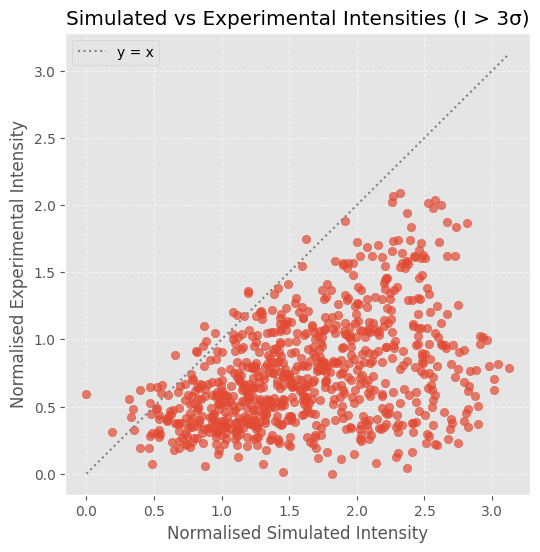

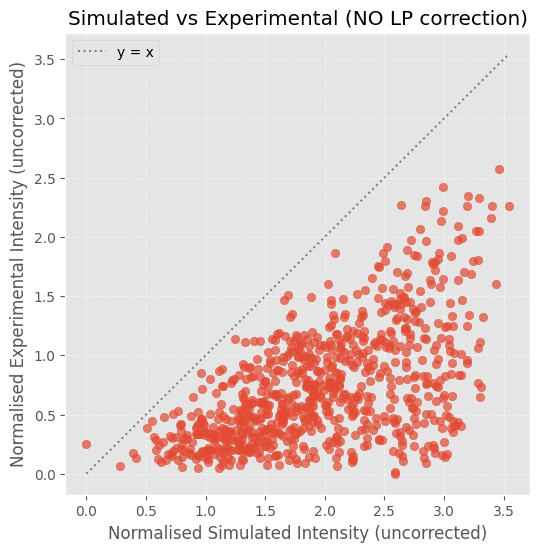

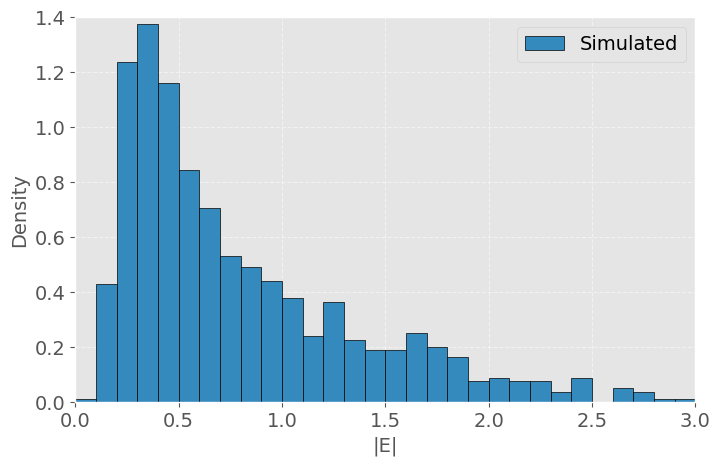

In [ ]:
# Dynamical simulation vs experimental comparison
# Only reflections with I > 3σ in cif_pets are treated as observed

import csv
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. BUILD OBSERVED HKL SET FROM df_unique
# ===============================

observed_hkls = set()
exp_intensity_map = {}

for _, row in df_unique.iterrows():

    hkl = (
        int(row["_refln_index_h"]),
        int(row["_refln_index_k"]),
        int(row["_refln_index_l"])
    )

    I = float(row["lpcorrected_intensity"])

    if I > 0:
        observed_hkls.add(hkl)
        exp_intensity_map[hkl] = I

print("Number of observed HKLs:", len(observed_hkls))

# ===============================
# 2. MATCH SIMULATED INTENSITIES
# ===============================

sim_intensity_map = {}
duplicate_hkls = set()

for rot in range(1, 112):

    simulation = f'/content/rotation_{rot}_intensities.csv'

    with open(simulation, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:

            hkl = tuple(int(x) for x in row["HKL"].split())
            intensity = float(row["Intensity"])

            if hkl in observed_hkls and intensity > 0:

                if hkl in sim_intensity_map:
                    duplicate_hkls.add(hkl)

                else:
                    I_sim = intensity

                    if hkl in lp_lookup and lp_lookup[hkl] is not None:
                        I_sim = I_sim * lp_lookup[hkl]

                    sim_intensity_map[hkl] = I_sim

print('number of duplicates is', len(duplicate_hkls))

# ===============================
# 3. MATCH COMMON HKLs
# ===============================

common_hkls = set(exp_intensity_map.keys()) & set(sim_intensity_map.keys())

print("Number of matched HKLs:", len(common_hkls))

sim_vals = []
exp_vals = []

for hkl in common_hkls:
    sim_I = sim_intensity_map[hkl]
    exp_I = exp_intensity_map[hkl]

    if sim_I > 0 and exp_I > 0:
        sim_vals.append(sim_I)
        exp_vals.append(exp_I)

sim_vals = np.array(sim_vals, dtype=float)
exp_vals = np.array(exp_vals, dtype=float)

# ===============================
# 4. NORMALISE BY MEAN
# ===============================

sim_norm = sim_vals / np.mean(sim_vals)
exp_norm = exp_vals / np.mean(exp_vals)

# ===============================
# 5. LOG–LOG SCATTER PLOT (SHIFTED TO START AT 0)
# ===============================

x = np.log10(sim_norm)
y = np.log10(exp_norm)

# shift so axes start at 0
x -= np.min(x)
y -= np.min(y)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Normalised Simulated Intensity")
plt.ylabel("Normalised Experimental Intensity")
plt.title("Simulated vs Experimental Intensities (I > 3σ)")
plt.grid(True, linestyle='--', alpha=0.5)

# y = x line
x_line = np.linspace(0, max(x), 100)
plt.plot(x_line, x_line, linestyle=":", color="gray", label="y = x")

plt.legend()
plt.show()
plt.close()

# ============================================
# UNC0RRECTED (NO LP) SIMULATED vs EXPERIMENTAL
# ============================================

uncorr_exp_map = {}
uncorr_sim_map = {}

# -------------------------------
# 1. Experimental (raw intensities)
# -------------------------------
for _, row in df_unique.iterrows():

    hkl = (
        int(row["_refln_index_h"]),
        int(row["_refln_index_k"]),
        int(row["_refln_index_l"])
    )

    I_raw = float(row["_refln_intensity_meas"])

    if I_raw > 0:
        uncorr_exp_map[hkl] = I_raw

# -------------------------------
# 2. Simulated (raw intensities)
# -------------------------------
for rot in range(1, 112):

    simulation = f'/content/rotation_{rot}_intensities.csv'

    with open(simulation, newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:

            hkl = tuple(int(x) for x in row["HKL"].split())
            I_sim_raw = float(row["Intensity"])

            if I_sim_raw > 0 and hkl not in uncorr_sim_map:
                uncorr_sim_map[hkl] = I_sim_raw

# -------------------------------
# 3. Match HKLs
# -------------------------------
uncorr_common = set(uncorr_exp_map.keys()) & set(uncorr_sim_map.keys())

uncorr_exp_vals = np.array([uncorr_exp_map[h] for h in uncorr_common], dtype=float)
uncorr_sim_vals = np.array([uncorr_sim_map[h] for h in uncorr_common], dtype=float)

mask = (uncorr_exp_vals > 0) & (uncorr_sim_vals > 0)
uncorr_exp_vals = uncorr_exp_vals[mask]
uncorr_sim_vals = uncorr_sim_vals[mask]

# -------------------------------
# 4. Normalise
# -------------------------------
uncorr_exp_norm = uncorr_exp_vals / np.mean(uncorr_exp_vals)
uncorr_sim_norm = uncorr_sim_vals / np.mean(uncorr_sim_vals)

# -------------------------------
# 5. Plot (SHIFTED TO START AT 0)
# -------------------------------

x_unc = np.log10(uncorr_sim_norm)
y_unc = np.log10(uncorr_exp_norm)

x_unc -= np.min(x_unc)
y_unc -= np.min(y_unc)

plt.figure(figsize=(6, 6))
plt.scatter(x_unc, y_unc, alpha=0.7)

plt.xlabel("Normalised Simulated Intensity (uncorrected)")
plt.ylabel("Normalised Experimental Intensity (uncorrected)")
plt.title("Simulated vs Experimental (NO LP correction)")
plt.grid(True, linestyle='--', alpha=0.5)

x_line = np.linspace(0, max(x_unc), 100)
plt.plot(x_line, x_line, linestyle=":", color="gray", label="y = x")

plt.legend()
plt.show()
plt.close()

# ===============================
# 4. CALCULATE |E|
# ===============================

sim_mean = np.mean(sim_vals)
E_sim = np.sqrt(sim_vals / sim_mean)
E_sim = E_sim[E_sim < 3]

exp_matched_vals = np.array([exp_intensity_map[hkl] for hkl in common_hkls], dtype=float)
exp_matched_vals = exp_matched_vals[exp_matched_vals > 0]

exp_mean = np.mean(exp_matched_vals)
E_exp = np.sqrt(exp_matched_vals / exp_mean)
E_exp = E_exp[E_exp < 3]

# ===============================
# 5. PLOT |E| DENSITY HISTOGRAM
# ===============================

bins = np.linspace(0, 3, 31)

plt.figure(figsize=(8, 5))

plt.hist(E_sim, bins=bins, alpha=1, density=True,
         label="Simulated", edgecolor="black", linewidth=0.5, color="C1")

plt.xlabel("|E|", size=14)
plt.ylabel("Density", size=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=14)
plt.xlim(0, 3)
plt.ylim(0, 1.4)
plt.xticks(size=14)
plt.yticks(size=14)
plt.savefig("sim_hist.pdf", dpi=600)
plt.show()
plt.close()

In [ ]:
#Plot to find -2B gradient

zone_id = np.array(data['_refln_zone_axis_id'], dtype=int)
gradient = []
for ori in range(1, int(np.max(zone_id)) + 1):

    mask = (zone_id == ori)

    if not np.any(mask):
        continue  # skip empty orientations

    lpcorr = np.array(data['lpcorrected_intensity'], dtype=float)[mask]
    g_mag = np.array(data['g_mag'], dtype=float)[mask]

    s_2 = (g_mag / 2)**2
    if ori == 50:
        plt.figure(figsize=(8,5))
        plt.plot(s_2, np.log(lpcorr), 'o', label=f'ori {ori}')
        plt.xlabel(r'$s^2$')
        plt.ylabel('ln of Lorentz-corrected intensity')
        plt.legend()
        plt.show()
    m,c = np.polyfit(s_2, np.log(lpcorr), 1)
    gradient.append(m)
plt.plot(np.arange(len(gradient)), gradient, 'o')
plt.xlabel('Orientation')
plt.ylabel('Gradient')
plt.title('Gradient vs Orientation')
plt.grid(True)
plt.show()



KeyError: 'lpcorrected_intensity'

In [ ]:
#Apply cutoff for previous plot

cutoff=input("Would you like to put a cutoff? ")
# apply cutoff if provided
if cutoff is not None:
    cutoff = float(cutoff)
    mask_cut = (E < cutoff)  # boolean array
    E = E[mask_cut]
    plt.figure(figsize=(8,5))
    plt.hist(E, bins=60, color='skyblue', edgecolor='black')
    plt.xlabel('|E|')
    plt.ylabel('Count')
    plt.title('Histogram of |E| for selected zone axis')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [ ]:
#Apply cutoff for previous plot

cutoff=input("Would you like to put a cutoff? ")
# apply cutoff if provided
if cutoff is not None:
    cutoff = float(cutoff)
    mask_cut = (norm_kinetic_inten_filtered < cutoff)  # boolean array
    normkinetic_filteredmask = norm_kinetic_inten_filtered[mask_cut]
    plt.figure(figsize=(8,5))
    plt.hist(normkinetic_filteredmask, bins=60, color='skyblue', edgecolor='black')
    plt.xlabel('|E|')
    plt.ylabel('Count')
    plt.title('Histogram of |E| for selected zone axis')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

In [ ]:
# ============================================================
# (1) LOAD DETECTED PEAKS FROM DIFFRACTION FRAME
# ============================================================
df_detected = pd.read_csv("peaks_frame_0180.txt")


# ============================================================
# (2) PREPARE HKL DATABASE FROM df_unique
# ============================================================
df_hkl_all = df_unique.copy()

# Filter by desired virtual frame (example: zone axis ID = 2)
df_hkl_filt = df_hkl_all[df_hkl_all["_refln_zone_axis_id"] == 90].copy()

# Rename columns for uniformity
df_hkl_filt = df_hkl_filt.rename(columns={
    "_refln_index_h": "h",
    "_refln_index_k": "k",
    "_refln_index_l": "l",
    "g_mag": "g_calc"
})

df_hkl_filt = df_hkl_filt[["h", "k", "l", "g_calc", "_refln_zone_axis_id"]]


# ============================================================
# (3) MATCH FUNCTION — now WITH tolerance filter
# ============================================================
def match_peaks_to_hkls_simplified(df_peaks, df_hkl, n_closest=3, tolerance=0.01):
    """Match each detected peak to up to n_closest HKLs,
    but only keep those with |q - g| < tolerance.
    """
    results = []

    for idx, row in df_peaks.iterrows():
        q_meas = row["q_spacing_A^-1"]

        # Compute |q - g|
        df_hkl["delta_q"] = np.abs(df_hkl["g_calc"] - q_meas)

        # Take the nearest N
        df_close = df_hkl.nsmallest(n_closest, "delta_q")

        # Apply tolerance filter: |q - g| < 0.01
        df_filtered = df_close[df_close["delta_q"] < tolerance]

        # If nothing passes tolerance → skip this peak
        if len(df_filtered) == 0:
            continue

        # Save only the small set of columns you want
        for _, hkl_row in df_filtered.iterrows():
            results.append({
                "peak_idx": row["peak_idx"],
                "q_measured": q_meas,
                "h": hkl_row["h"],
                "k": hkl_row["k"],
                "l": hkl_row["l"],
                "g_expected": hkl_row["g_calc"],
                "zone_axis": hkl_row["_refln_zone_axis_id"]
            })

    return pd.DataFrame(results)


# ============================================================
# (4) RUN MATCHING
# ============================================================
df_matched = match_peaks_to_hkls_simplified(
    df_detected,
    df_hkl_filt,
    n_closest=3,
    tolerance=0.005   # ✅ your requested filter
)

df_matched.to_csv("matched_peaks_frame0004_simplified.txt", index=False)
print("Saved simplified + tolerance‑filtered matches → matched_peaks_frame0004_simplified.txt")


# ============================================================
# (5) Optionally extract arrays for later analysis
# ============================================================
peak_idx_arr = df_matched["peak_idx"].values
q_measured_arr = df_matched["q_measured"].values
h_arr = df_matched["h"].values
k_arr = df_matched["k"].values
l_arr = df_matched["l"].values
g_expected_arr = df_matched["g_expected"].values
zone_axis_arr = df_matched["zone_axis"].values

print("Filtered matches:", len(df_matched))